In [950]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC'];
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
%graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
database=['llnl.dat'];

# MODEL

$$\dfrac{d(portlandite)}{dt} = k_P X_P \left(1-\left(\dfrac{IAP_P}{Ksp_P}\right)\right)$$

$$\dfrac{d(calcite)}{dt} = k_C X_C \left(1-\left(\dfrac{IAP_C}{Ksp_C}\right)^\sigma\right)$$

$$\dfrac{d(DIC)}{dt} = k_{CO2} * \left(1-\left(\dfrac{[HCO3]_{PHREEQC}}{[HCO3]_{eq}}\right)\right)$$

In [951]:
% variables

% amounts
%XP=0.5;  % there was almost 0.03 mol/L maximum Ca conc  at the beginning of the experiment.  (0.0226 mol/L from measured data (Below))
XC=1e-6; % need seed crystal of calcite.  batstone paper used 1e-6

mass=6; %g of cement. that is 15-25% by weight.
massCaOH2=mass*0.20; molport=massCaOH2/74.093;
Vol=1; % volume of the bioreactor
XP=molport/Vol;

XP=0.027;

%equilib constants
%KspP=0.00000660693;  % from https://www.aqion.de/site/16 0.00000660693
%KspC=3.31131121e-9;  % Ksp for calcite
%KspC=10^-8.46249;
%KspC=4.7e-9;  % Ksp for calcite
%KspC=1e-14;
%Ksp=3.8e-9;
%logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room

% rate constants
kP=9e-1; %port dissoltuion
kC=0.04e-2; %calciate ppte
kCO2=0.63e-3; % gas transfer


% length of time to run the simulation
logtime=0.05:0.05:2.2; timetry=[0 10.^logtime];

%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00];

%pfit=[-3.37506	-2.50976	-4.22229];
%kP=10^pfit(1); kC=10^pfit(2); kCO2=10^pfit(3);


In [952]:
flag=2; %flag 1 for on NAS and 2 for running locally
[Ca,pH,DIC,port,calcite,time]=CO2CaCO3lowCaOH2kineticmodel(XP,kP,kC,kCO2,timetry,flag);

# play with the % occuring as CaOH2  if need more Ca that is a way to get it.

just occoured to me.  that CaOH2 should match the CO2 removal.

In [953]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH A	DIC A (mmol/L)	Conductivity A (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	5.84	-0.1881	NaN	0.01702	-0.03982
0.10	11.96	0.7954	2419	4.96925	0.08025
2.00	11.99	1.0141	3390	3.80725	0.02971
24.00	11.3	0.7376	990	0.77950	0.22411
48.00	8.73	0.5577	496	1.92998	0.57714
72.00	8.15	1.1859	557	1.90958	1.15143
96.00	8.15	1.1150	554	1.83288	1.07643
144.00	8.13	1.0494	606	1.84188	1.02107
0.00	5.61	-0.2068 NaN		0.00676	-0.04007
0.10	12.04	0.8275	2608	5.04350	0.08868
2.00	12.15	0.6705	3430	6.72050	0.04064
24.00	11.34	2.0533	871	1.99965	0.26911
48.00	8.55	0.7090	494	1.95345	0.69750
72.00	8.12	1.1136	567	1.85363	1.13643
96.00	8.08	1.1206	538	1.81123	1.09679
144.00	8.10	0.9826	597	1.80800	1.04643
0.00	11.84	0.2322	NaN	0.04982	-0.00836
0.10	11.68	0.9485	2304.0	5.06950	0.09996
2.00	11.92	1.0993	5030	8.65500	0.05936
24.00	11.02	1.1953	1443	2.00810	0.31064
48.00	8.39	1.0427	563	2.04983	0.94643
72.00	8.19	1.1912	695	1.93080	1.13143
96.00	8.18	1.0197	701	1.94583	1.08000
144.00	8.13	0.9578	725	1.88958	0.97643
];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);

higherres=[...
0.00	5.84
0.00	11.92
0.13	11.96
0.17	11.98
0.47	11.99
1.85	11.99
2.07	11.99
21.17	11.41
23.43	11.3
24.70	11.23
26.92	11.09
44.00	9.4
45.87	9.06
46.55	8.93
47.92	8.73
48.65	8.64
49.30	8.59
50.90	8.51
51.20	8.5
51.83	8.45
56.78	8.28
69.48	8.17
70.32	8.17
72.02	8.15
75.08	8.17
93.00	8.15
97.30	8.15
144.17	8.13
];

timeres=higherres(:,1); pHres=higherres(:,2);



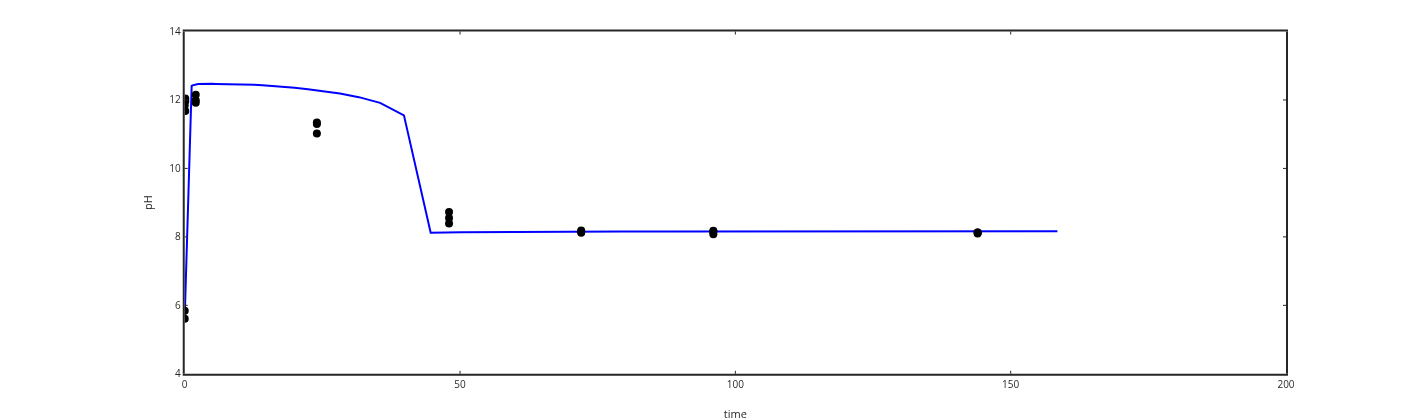

In [954]:

plot(time,pH,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

%yi = interp1 (time, pH, sampletime);
%plot(sampletime,yi,'r.')
%residual1=samplepH-yi;

%time
%pH
%sampletime
%samplepH


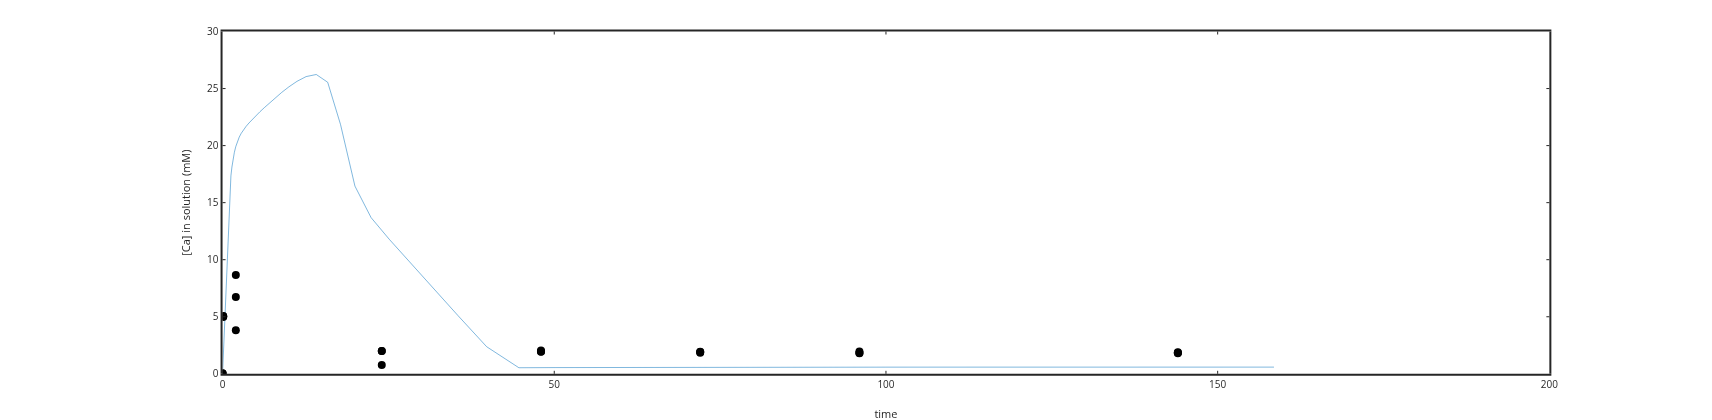

In [955]:
%plot(time(4:length(time)),Ca(4:length(time))); ylabel('[Ca] in solution'); xlabel('time')
plot(time,(Ca*1e3)); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

%yi = interp1 (time, Ca, sampletime);
%plot(sampletime,yi*1e3,'r.')
%residual2=sampleCa*1e3-yi*1e3;

%sampleCa
%Ca


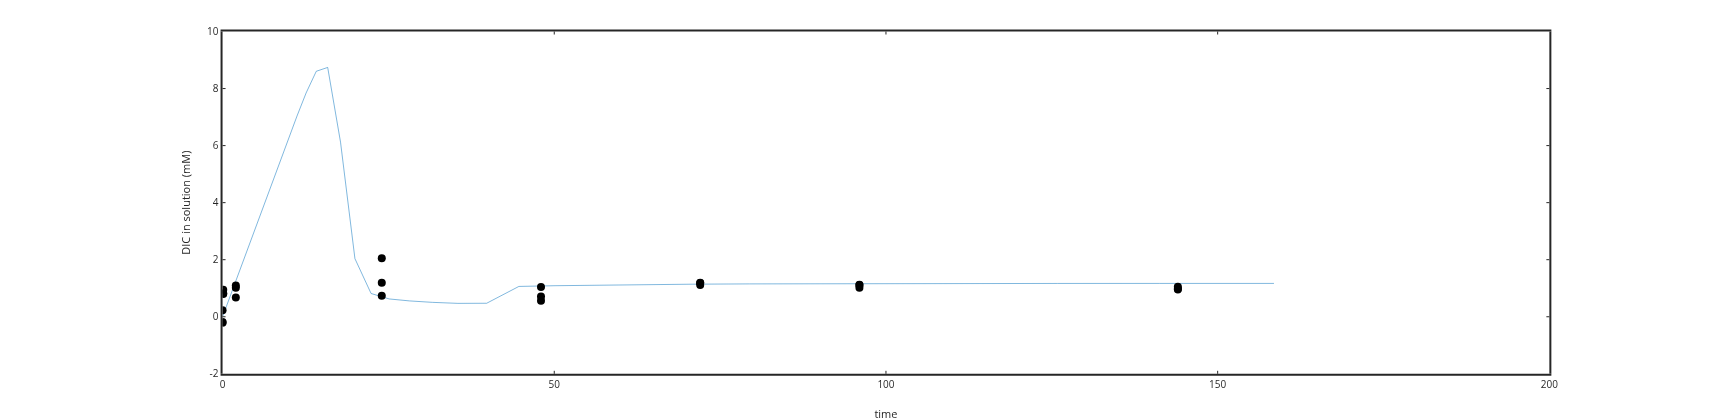

In [956]:
plot(time(1:length(time)),1e3*DIC(1:length(time))); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

yi = interp1 (time, DIC, sampletime);
%plot(sampletime,yi*1e3,'r.')

residual3=sampleDIC*1e3-yi*1e3;

%DIC
%sampleDIC


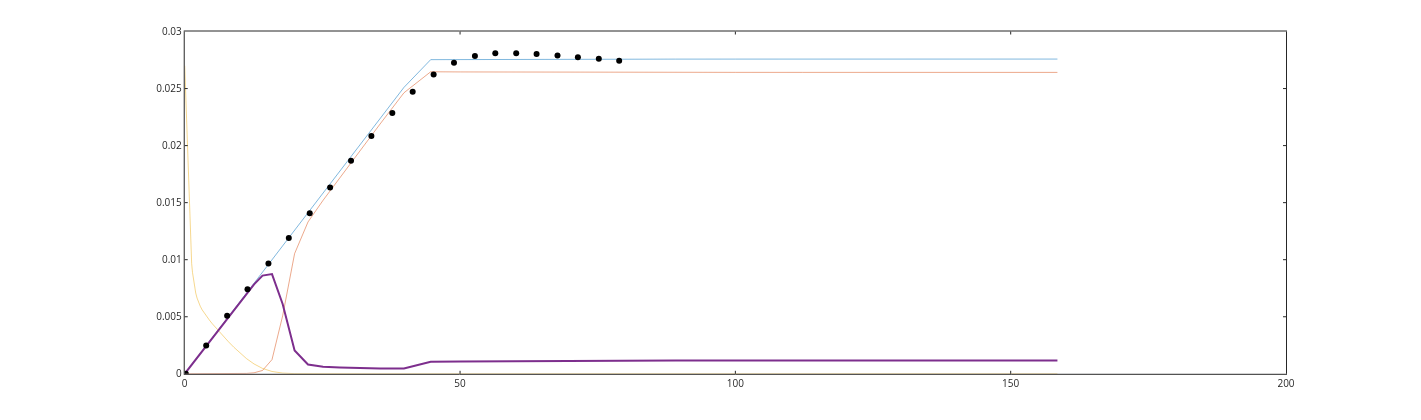

In [957]:
% plot total C that ends up in solution

CTsoln=DIC+calcite;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcite,time,port,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)		CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
9	0.2	402.7		5.67673378076063E-05	4.86561704834606E-05	0.00000811117 	8.1 	97.3 	8.1 
14	0.2	252.9		5.89685202940237E-05	3.05542302798982E-05	0.00002841429 	28.4 	341.0 	36.5 
19	0.3	157.4		5.73465963566635E-05	1.90243320610687E-05	0.00003832226 	38.3 	459.9 	74.8 
24	0.4	90.6		5.95477788430809E-05	1.0953403307888E-05	0.00004859438 	48.6 	583.1 	123.4 
29	0.5	56.3		6.02428891019495E-05	6.80263994910941E-06	0.00005344025 	53.4 	641.3 	176.9 
34	0.6	36.3		6.05904442313838E-05	4.38136132315522E-06	0.00005620908 	56.2 	674.5 	233.1 
39	0.7	26.7		5.66514860977948E-05	3.22837150127226E-06	0.00005342311 	53.4 	641.1 	286.5 
44	0.7	19.1		5.78100031959092E-05	2.3059796437659E-06	0.00005550402 	55.5 	666.0 	342.0 
49	0.8	21.0		5.97794822627038E-05	2.53657760814249E-06	0.00005724290 	57.2 	686.9 	399.3 
54	0.9	25.8		5.89685202940237E-05	3.11307251908397E-06	0.00005585545 	55.9 	670.3 	455.1 
59	1.0	22.9		5.90843720038351E-05	2.76717557251908E-06	0.00005631720 	56.3 	675.8 	511.4 
64	1.1	21.9		5.96636305528923E-05	2.65187659033079E-06	0.00005701175 	57.0 	684.1 	568.4 
69	1.2	17.2		5.8273410035155E-05	2.07538167938931E-06	0.00005619803 	56.2 	674.4 	624.6 
74	1.2	16.2		5.8273410035155E-05	1.96008269720102E-06	0.00005631333 	56.3 	675.8 	681.0 
79	1.3	31.5		6.02428891019495E-05	3.80486641221374E-06	0.00005643802 	56.4 	677.3 	737.4 
84	1.4	17.2		6.29074784276127E-05	2.07538167938931E-06	0.00006083210 	60.8 	730.0 	798.2 
89	1.5	18.1		5.98953339725152E-05	2.19068066157761E-06	0.00005770465 	57.7 	692.5 	855.9 
94	1.6	11.5		5.71148929370406E-05	1.38358778625954E-06	0.00005573131 	55.7 	668.8 	911.7 
99	1.7	19.1		5.80417066155321E-05	2.3059796437659E-06	0.00005573573 	55.7 	668.8 	967.4 
104	1.7	13.4		6.01270373921381E-05	1.61418575063613E-06	0.00005851285 	58.5 	702.2 	1025.9 
109	1.8	21.9		5.92002237136465E-05	2.65187659033079E-06	0.00005654835 	56.5 	678.6 	1082.5 
114	1.9	21.0		5.83892617449664E-05	2.53657760814249E-06	0.00005585268 	55.9 	670.2 	1138.3 
119	2.0	26.7		5.90843720038351E-05	3.22837150127226E-06	0.00005585600 	55.9 	670.3 	1194.2 
124	2.1	23.9		5.92002237136465E-05	2.88247455470738E-06	0.00005631775 	56.3 	675.8 	1250.5 
129	2.2	15.3		5.92002237136465E-05	1.84478371501272E-06	0.00005735544 	57.4 	688.3 	1307.8 
134	2.2	25.8		6.05904442313838E-05	3.11307251908397E-06	0.00005747737 	57.5 	689.7 	1365.3 
139	2.3	19.1		6.10538510706296E-05	2.3059796437659E-06	0.00005874787 	58.7 	705.0 	1424.1 
144	2.4	15.3		5.98953339725152E-05	1.84478371501272E-06	0.00005805055 	58.1 	696.6 	1482.1 
149	2.5	30.5		5.83892617449664E-05	3.68956743002544E-06	0.00005469969 	54.7 	656.4 	1536.8 
154	2.6	18.1		5.79258549057207E-05	2.19068066157761E-06	0.00005573517 	55.7 	668.8 	1592.6 
159	2.7	23.9		5.8273410035155E-05	2.88247455470738E-06	0.00005539094 	55.4 	664.7 	1647.9 
164	2.7	22.9		6.12855544902525E-05	2.76717557251908E-06	0.00005851838 	58.5 	702.2 	1706.5 
169	2.8	24.8		5.78100031959092E-05	2.99777353689567E-06	0.00005481223 	54.8 	657.7 	1761.3 
174	2.9	21.9		5.98953339725152E-05	2.65187659033079E-06	0.00005724346 	57.2 	686.9 	1818.5 
179	3.0	23.9		5.90843720038351E-05	2.88247455470738E-06	0.00005620190 	56.2 	674.4 	1874.7 
184	3.1	29.6		5.88526685842122E-05	3.57426844783715E-06	0.00005527840 	55.3 	663.3 	1930.0 
189	3.2	23.9		5.81575583253436E-05	2.88247455470738E-06	0.00005527508 	55.3 	663.3 	1985.3 
194	3.2	18.1		5.9316075423458E-05	2.19068066157761E-06	0.00005712539 	57.1 	685.5 	2042.4 
199	3.3	29.6		5.94319271332694E-05	3.57426844783715E-06	0.00005585766 	55.9 	670.3 	2098.3 
204	3.4	27.7		5.79258549057207E-05	3.34367048346056E-06	0.00005458218 	54.6 	655.0 	2152.8 
209	3.5	24.8		5.8273410035155E-05	2.99777353689567E-06	0.00005527564 	55.3 	663.3 	2208.1 
214	3.6	21.0		5.92002237136465E-05	2.53657760814249E-06	0.00005666365 	56.7 	680.0 	2264.8 
219	3.7	23.9		5.88526685842122E-05	2.88247455470738E-06	0.00005597019 	56.0 	671.6 	2320.7 
224	3.7	26.7		6.07062959411953E-05	3.22837150127226E-06	0.00005747792 	57.5 	689.7 	2378.2 
229	3.8	26.7		5.86209651645893E-05	3.22837150127226E-06	0.00005539259 	55.4 	664.7 	2433.6 
234	3.9	30.5		5.95477788430809E-05	3.68956743002544E-06	0.00005585821 	55.9 	670.3 	2489.5 
239	4.0	22.9		6.14014062000639E-05	2.76717557251908E-06	0.00005863423 	58.6 	703.6 	2548.1 
244	4.1	32.4		5.68831895174177E-05	3.92016539440204E-06	0.00005296302 	53.0 	635.6 	2601.1 
249	4.2	22.9		5.9316075423458E-05	2.76717557251908E-06	0.00005654890 	56.5 	678.6 	2657.6 
254	4.2	24.8		6.02428891019495E-05	2.99777353689567E-06	0.00005724512 	57.2 	686.9 	2714.9 
259	4.3	30.5		6.07062959411953E-05	3.68956743002544E-06	0.00005701673 	57.0 	684.2 	2771.9 
264	4.4	22.9		6.01270373921381E-05	2.76717557251908E-06	0.00005735986 	57.4 	688.3 	2829.2 
269	4.5	20.0		5.97794822627038E-05	2.4212786259542E-06	0.00005735820 	57.4 	688.3 	2886.6 
274	4.6	21.0		5.86209651645893E-05	2.53657760814249E-06	0.00005608439 	56.1 	673.0 	2942.7 
279	4.7	32.4		5.98953339725152E-05	3.92016539440204E-06	0.00005597517 	56.0 	671.7 	2998.7 
284	4.7	27.7		5.79258549057207E-05	3.34367048346056E-06	0.00005458218 	54.6 	655.0 	3053.2 
289	4.8	32.4		6.05904442313838E-05	3.92016539440204E-06	0.00005667028 	56.7 	680.0 	3109.9 
294	4.9	22.9		6.08221476510067E-05	2.76717557251908E-06	0.00005805497 	58.1 	696.7 	3168.0 
299	5.0	33.4		5.85051134547779E-05	4.03546437659033E-06	0.00005446965 	54.5 	653.6 	3222.4 
304	5.1	29.6		6.14014062000639E-05	3.57426844783715E-06	0.00005782714 	57.8 	693.9 	3280.3 
309	5.2	22.9		6.16331096196868E-05	2.76717557251908E-06	0.00005886593 	58.9 	706.4 	3339.1 
314	5.2	29.6		5.96636305528923E-05	3.57426844783715E-06	0.00005608936 	56.1 	673.1 	3395.2 
319	5.3	21.0		6.08221476510067E-05	2.53657760814249E-06	0.00005828557 	58.3 	699.4 	3453.5 
324	5.4	29.6		6.15172579098754E-05	3.57426844783715E-06	0.00005794299 	57.9 	695.3 	3511.5 
329	5.5	29.6		6.10538510706296E-05	3.57426844783715E-06	0.00005747958 	57.5 	689.8 	3568.9 
334	5.6	33.4		6.26757750079898E-05	4.03546437659033E-06	0.00005864031 	58.6 	703.7 	3627.6 
339	5.7	21.0		6.02428891019495E-05	2.53657760814249E-06	0.00005770631 	57.7 	692.5 	3685.3 
344	5.7	27.7		5.98953339725152E-05	3.34367048346056E-06	0.00005655166 	56.6 	678.6 	3741.8 
349	5.8	26.7		6.18648130393097E-05	3.22837150127226E-06	0.00005863644 	58.6 	703.6 	3800.5 
354	5.9	22.9		6.09379993608182E-05	2.76717557251908E-06	0.00005817082 	58.2 	698.0 	3858.6 
359	6.0	18.1		6.2212368168744E-05	2.19068066157761E-06	0.00006002169 	60.0 	720.3 	3918.7 
364	6.1	36.3		6.36025886864813E-05	4.38136132315522E-06	0.00005922123 	59.2 	710.7 	3977.9 
369	6.2	27.7		6.30233301374241E-05	3.34367048346056E-06	0.00005967966 	59.7 	716.2 	4037.6 
374	6.2	24.8		6.29074784276127E-05	2.99777353689567E-06	0.00005990970 	59.9 	718.9 	4097.5 
379	6.3	23.9		6.38342921061042E-05	2.88247455470738E-06	0.00006095182 	61.0 	731.4 	4158.4 
384	6.4	26.7		6.2212368168744E-05	3.22837150127226E-06	0.00005898400 	59.0 	707.8 	4217.4 
389	6.5	27.7		6.15172579098754E-05	3.34367048346056E-06	0.00005817359 	58.2 	698.1 	4275.6 
394	6.6	20.0		6.37184403962928E-05	2.4212786259542E-06	0.00006129716 	61.3 	735.6 	4336.9 
399	6.7	29.6		6.24440715883669E-05	3.57426844783715E-06	0.00005886980 	58.9 	706.4 	4395.7 
404	6.7	31.5		6.41818472355385E-05	3.80486641221374E-06	0.00006037698 	60.4 	724.5 	4456.1 
409	6.8	20.0		5.95477788430809E-05	2.4212786259542E-06	0.00005712650 	57.1 	685.5 	4513.2 
414	6.9	27.7		6.27916267178012E-05	3.34367048346056E-06	0.00005944796 	59.4 	713.4 	4572.7 
419	7.0	23.9		6.27916267178012E-05	2.88247455470738E-06	0.00005990915 	59.9 	718.9 	4632.6 
424	7.1	26.7		6.19806647491211E-05	3.22837150127226E-06	0.00005875229 	58.8 	705.0 	4691.4 
429	7.2	40.1		6.09379993608182E-05	4.8425572519084E-06	0.00005609544 	56.1 	673.1 	4747.5 
434	7.2	36.3		5.74624480664749E-05	4.38136132315522E-06	0.00005308109 	53.1 	637.0 	4800.5 
439	7.3	36.3		5.68831895174177E-05	4.38136132315522E-06	0.00005250183 	52.5 	630.0 	4853.0 
444	7.4	44.8		5.9316075423458E-05	5.41905216284987E-06	0.00005389702 	53.9 	646.8 	4906.9 
449	7.5	27.7		6.23282198785554E-05	3.34367048346056E-06	0.00005898455 	59.0 	707.8 	4965.9 
454	7.6	32.4		6.17489613294982E-05	3.92016539440204E-06	0.00005782880 	57.8 	693.9 	5023.7 
459	7.7	39.1		6.29074784276127E-05	4.7272582697201E-06	0.00005818022 	58.2 	698.2 	5081.9 
464	7.7	36.3		5.97794822627038E-05	4.38136132315522E-06	0.00005539812 	55.4 	664.8 	5137.3 
469	7.8	32.4		6.10538510706296E-05	3.92016539440204E-06	0.00005713369 	57.1 	685.6 	5194.5 
474	7.9	35.3		5.83892617449664E-05	4.26606234096692E-06	0.00005412320 	54.1 	649.5 	5248.6 
479	8.0	43.9		5.89685202940237E-05	5.30375318066158E-06	0.00005366477 	53.7 	644.0 	5302.2 
484	8.1	32.4		5.74624480664749E-05	3.92016539440204E-06	0.00005354228 	53.5 	642.5 	5355.8 
489	8.2	37.2		5.69990412272292E-05	4.49666030534351E-06	0.00005250238 	52.5 	630.0 	5408.3 
494	8.2	34.4		5.80417066155321E-05	4.15076335877862E-06	0.00005389094 	53.9 	646.7 	5462.2 
499	8.3	34.4		5.65356343879834E-05	4.15076335877862E-06	0.00005238487 	52.4 	628.6 	5514.6 
504	8.4	42.9		5.57246724193033E-05	5.18845419847328E-06	0.00005053622 	50.5 	606.4 	5565.1 
509	8.5	32.4		5.60722275487376E-05	3.92016539440204E-06	0.00005215206 	52.2 	625.8 	5617.3 
514	8.6	34.4		5.86209651645893E-05	4.15076335877862E-06	0.00005447020 	54.5 	653.6 	5671.7 
519	8.7	37.2		5.61880792585491E-05	4.49666030534351E-06	0.00005169142 	51.7 	620.3 	5723.4 
524	8.7	41.0		5.5377117289869E-05	4.95785623409669E-06	0.00005041926 	50.4 	605.0 	5773.8 
529	8.8	39.1		5.61880792585491E-05	4.7272582697201E-06	0.00005146082 	51.5 	617.5 	5825.3 
534	8.9	23.9		5.51454138702461E-05	2.88247455470738E-06	0.00005226294 	52.3 	627.2 	5877.6 
539	9.0	33.4		5.71148929370406E-05	4.03546437659033E-06	0.00005307943 	53.1 	637.0 	5930.6 
544	9.1	47.7		5.85051134547779E-05	5.76494910941476E-06	0.00005274016 	52.7 	632.9 	5983.4 
549	9.2	41.0		5.64197826781719E-05	4.95785623409669E-06	0.00005146193 	51.5 	617.5 	6034.8 
554	9.2	31.5		5.78100031959092E-05	3.80486641221374E-06	0.00005400514 	54.0 	648.1 	6088.8 
559	9.3	41.0		5.64197826781719E-05	4.95785623409669E-06	0.00005146193 	51.5 	617.5 	6140.3 
564	9.4	44.8		5.67673378076063E-05	5.41905216284987E-06	0.00005134829 	51.3 	616.2 	6191.7 
569	9.5	44.8		5.63039309683605E-05	5.41905216284987E-06	0.00005088488 	50.9 	610.6 	6242.5 
574	9.6	33.4		5.56088207094919E-05	4.03546437659033E-06	0.00005157336 	51.6 	618.9 	6294.1 
579	9.7	34.4		5.7230744646852E-05	4.15076335877862E-06	0.00005307998 	53.1 	637.0 	6347.2 
584	9.7	36.3		5.66514860977948E-05	4.38136132315522E-06	0.00005227012 	52.3 	627.2 	6399.5 
589	9.8	31.5		5.60722275487376E-05	3.80486641221374E-06	0.00005226736 	52.3 	627.2 	6451.7 
594	9.9	39.1		5.54929689996804E-05	4.7272582697201E-06	0.00005076571 	50.8 	609.2 	6502.5 
599	10.0	29.6		5.4334451901566E-05	3.57426844783715E-06	0.00005076018 	50.8 	609.1 	6553.3 
604	10.1	41.0		5.87368168744008E-05	4.95785623409669E-06	0.00005377896 	53.8 	645.3 	6607.0 
609	10.2	31.5		5.67673378076063E-05	3.80486641221374E-06	0.00005296247 	53.0 	635.5 	6660.0 
614	10.2	44.8		5.68831895174177E-05	5.41905216284987E-06	0.00005146414 	51.5 	617.6 	6711.5 
619	10.3	40.1		5.78100031959092E-05	4.8425572519084E-06	0.00005296745 	53.0 	635.6 	6764.4 
624	10.4	42.9		5.38710450623202E-05	5.18845419847328E-06	0.00004868259 	48.7 	584.2 	6813.1 
629	10.5	36.3		5.65356343879834E-05	4.38136132315522E-06	0.00005215427 	52.2 	625.9 	6865.3 
634	10.6	51.5		5.63039309683605E-05	6.22614503816794E-06	0.00005007779 	50.1 	600.9 	6915.3 
639	10.7	32.4		5.4334451901566E-05	3.92016539440204E-06	0.00005041429 	50.4 	605.0 	6965.8 
644	10.7	48.7		5.59563758389262E-05	5.88024809160305E-06	0.00005007613 	50.1 	600.9 	7015.8 
649	10.8	46.8		5.4334451901566E-05	5.64965012722646E-06	0.00004868480 	48.7 	584.2 	7064.5 
654	10.9	37.2		5.68831895174177E-05	4.49666030534351E-06	0.00005238653 	52.4 	628.6 	7116.9 
659	11.0	39.1		5.66514860977948E-05	4.7272582697201E-06	0.00005192423 	51.9 	623.1 	7168.8 
664	11.1	43.9		5.46820070310003E-05	5.30375318066158E-06	0.00004937825 	49.4 	592.5 	7218.2 
669	11.2	46.8		5.52612655800575E-05	5.64965012722646E-06	0.00004961162 	49.6 	595.3 	7267.8 
674	11.2	44.8		5.4334451901566E-05	5.41905216284987E-06	0.00004891540 	48.9 	587.0 	7316.7 
679	11.3	39.1		5.42186001917546E-05	4.7272582697201E-06	0.00004949134 	49.5 	593.9 	7366.2 
684	11.4	43.9		5.4334451901566E-05	5.30375318066158E-06	0.00004903070 	49.0 	588.4 	7415.3 
689	11.5	41.0		5.44503036113774E-05	4.95785623409669E-06	0.00004949245 	49.5 	593.9 	7464.8 
694	11.6	42.9		5.42186001917546E-05	5.18845419847328E-06	0.00004903015 	49.0 	588.4 	7513.8 
699	11.7	42.0		5.67673378076063E-05	5.07315521628499E-06	0.00005169418 	51.7 	620.3 	7565.5 
704	11.7	40.1		5.68831895174177E-05	4.8425572519084E-06	0.00005204063 	52.0 	624.5 	7617.5 
709	11.8	44.8		5.39868967721317E-05	5.41905216284987E-06	0.00004856784 	48.6 	582.8 	7666.1 
714	11.9	38.2		5.24808245445829E-05	4.61195928753181E-06	0.00004786887 	47.9 	574.4 	7714.0 
719	12.0	44.8		5.57246724193033E-05	5.41905216284987E-06	0.00005030562 	50.3 	603.7 	7764.3 
724	12.1	52.5		5.22491211249601E-05	6.34144402035623E-06	0.00004590768 	45.9 	550.9 	7810.2 
729	12.2	45.8		5.51454138702461E-05	5.53435114503817E-06	0.00004961106 	49.6 	595.3 	7859.8 
734	12.2	46.8		5.63039309683605E-05	5.64965012722646E-06	0.00005065428 	50.7 	607.9 	7910.4 
739	12.3	43.9		5.4334451901566E-05	5.30375318066158E-06	0.00004903070 	49.0 	588.4 	7959.5 
744	12.4	43.9		5.49137104506232E-05	5.30375318066158E-06	0.00004960996 	49.6 	595.3 	8009.1 
749	12.5	43.9		5.61880792585491E-05	5.30375318066158E-06	0.00005088433 	50.9 	610.6 	8060.0 
754	12.6	41.0		5.5377117289869E-05	4.95785623409669E-06	0.00005041926 	50.4 	605.0 	8110.4 
759	12.7	38.2		5.7230744646852E-05	4.61195928753181E-06	0.00005261879 	52.6 	631.4 	8163.0 
764	12.7	54.4		5.44503036113774E-05	6.57204198473282E-06	0.00004787826 	47.9 	574.5 	8210.9 
769	12.8	43.9		5.38710450623202E-05	5.30375318066158E-06	0.00004856729 	48.6 	582.8 	8259.4 
774	12.9	60.1		5.51454138702461E-05	7.2638358778626E-06	0.00004788158 	47.9 	574.6 	8307.3 
779	13.0	50.6		5.45661553211889E-05	6.11084605597964E-06	0.00004845531 	48.5 	581.5 	8355.8 
784	13.1	48.7		5.21332694151486E-05	5.88024809160305E-06	0.00004625302 	46.3 	555.0 	8402.0 
789	13.2	43.9		5.75782997762864E-05	5.30375318066158E-06	0.00005227455 	52.3 	627.3 	8454.3 
794	13.2	42.0		5.38710450623202E-05	5.07315521628499E-06	0.00004879789 	48.8 	585.6 	8503.1 
799	13.3	55.3		5.47978587408118E-05	6.68734096692112E-06	0.00004811052 	48.1 	577.3 	8551.2 
804	13.4	40.1		5.47978587408118E-05	4.8425572519084E-06	0.00004995530 	50.0 	599.5 	8601.2 
809	13.5	44.8		5.37551933525088E-05	5.41905216284987E-06	0.00004833614 	48.3 	580.0 	8649.5 
814	13.6	38.2		5.44503036113774E-05	4.61195928753181E-06	0.00004983834 	49.8 	598.1 	8699.3 
819	13.7	46.8		5.59563758389262E-05	5.64965012722646E-06	0.00005030673 	50.3 	603.7 	8749.6 
824	13.7	52.5		5.50295621604346E-05	6.34144402035623E-06	0.00004868812 	48.7 	584.3 	8798.3 
829	13.8	47.7		5.51454138702461E-05	5.76494910941476E-06	0.00004938046 	49.4 	592.6 	8847.7 
834	13.9	52.5		5.90843720038351E-05	6.34144402035623E-06	0.00005274293 	52.7 	632.9 	8900.5 
839	14.0	47.7		5.49137104506232E-05	5.76494910941476E-06	0.00004914876 	49.1 	589.8 	8949.6 
844	14.1	53.4		5.83892617449664E-05	6.45674300254453E-06	0.00005193252 	51.9 	623.2 	9001.5 
849	14.2	50.6		5.71148929370406E-05	6.11084605597964E-06	0.00005100405 	51.0 	612.0 	9052.5 
854	14.2	37.2		5.69990412272292E-05	4.49666030534351E-06	0.00005250238 	52.5 	630.0 	9105.0 
859	14.3	51.5		5.60722275487376E-05	6.22614503816794E-06	0.00004984608 	49.8 	598.2 	9154.9 
864	14.4	58.2		5.64197826781719E-05	7.03323791348601E-06	0.00004938654 	49.4 	592.6 	9204.3 
869	14.5	45.8		5.79258549057207E-05	5.53435114503817E-06	0.00005239150 	52.4 	628.7 	9256.7 
874	14.6	42.0		5.85051134547779E-05	5.07315521628499E-06	0.00005343196 	53.4 	641.2 	9310.1 
879	14.7	54.4		5.65356343879834E-05	6.57204198473282E-06	0.00004996359 	50.0 	599.6 	9360.1 
884	14.7	51.5		5.67673378076063E-05	6.22614503816794E-06	0.00005054119 	50.5 	606.5 	9410.6 
889	14.8	49.6		5.64197826781719E-05	5.99554707379135E-06	0.00005042424 	50.4 	605.1 	9461.0 
894	14.9	51.5		5.41027484819431E-05	6.22614503816794E-06	0.00004787660 	47.9 	574.5 	9508.9 
899	15.0	47.7		5.59563758389262E-05	5.76494910941476E-06	0.00005019143 	50.2 	602.3 	9559.1 
904	15.1	49.6		5.65356343879834E-05	5.99554707379135E-06	0.00005054009 	50.5 	606.5 	9609.6 
909	15.2	54.4		5.71148929370406E-05	6.57204198473282E-06	0.00005054285 	50.5 	606.5 	9660.2 
914	15.2	46.8		5.51454138702461E-05	5.64965012722646E-06	0.00004949576 	49.5 	593.9 	9709.7 
919	15.3	54.4		5.64197826781719E-05	6.57204198473282E-06	0.00004984774 	49.8 	598.2 	9759.5 
924	15.4	63.0		5.56088207094919E-05	7.60973282442748E-06	0.00004799909 	48.0 	576.0 	9807.5 
929	15.5	49.6		5.65356343879834E-05	5.99554707379135E-06	0.00005054009 	50.5 	606.5 	9858.1 
934	15.6	54.4		5.51454138702461E-05	6.57204198473282E-06	0.00004857337 	48.6 	582.9 	9906.6 
939	15.7	61.1		5.66514860977948E-05	7.37913486005089E-06	0.00004927235 	49.3 	591.3 	9955.9 
944	15.7	50.6		5.4334451901566E-05	6.11084605597964E-06	0.00004822361 	48.2 	578.7 	10004.1 
949	15.8	61.1		5.63039309683605E-05	7.37913486005089E-06	0.00004892480 	48.9 	587.1 	10053.1 
954	15.9	56.3		5.58405241291147E-05	6.80263994910941E-06	0.00004903788 	49.0 	588.5 	10102.1 
959	16.0	50.6		5.52612655800575E-05	6.11084605597964E-06	0.00004915042 	49.2 	589.8 	10151.2 
964	16.1	52.5		5.71148929370406E-05	6.34144402035623E-06	0.00005077345 	50.8 	609.3 	10202.0 
969	16.2	45.8		5.78100031959092E-05	5.53435114503817E-06	0.00005227565 	52.3 	627.3 	10254.3 
974	16.2	61.1		5.78100031959092E-05	7.37913486005089E-06	0.00005043087 	50.4 	605.2 	10304.7 
979	16.3	58.2		5.59563758389262E-05	7.03323791348601E-06	0.00004892314 	48.9 	587.1 	10353.7 
984	16.4	60.1		5.79258549057207E-05	7.2638358778626E-06	0.00005066202 	50.7 	607.9 	10404.3 
989	16.5	51.5		5.73465963566635E-05	6.22614503816794E-06	0.00005112045 	51.1 	613.4 	10455.4 
994	16.6	57.3		5.57246724193033E-05	6.91793893129771E-06	0.00004880673 	48.8 	585.7 	10504.2 
999	16.7	61.1		5.44503036113774E-05	7.37913486005089E-06	0.00004707117 	47.1 	564.9 	10551.3 
1004	16.7	57.3		5.57246724193033E-05	6.91793893129771E-06	0.00004880673 	48.8 	585.7 	10600.1 
1009	16.8	51.5		5.80417066155321E-05	6.22614503816794E-06	0.00005181556 	51.8 	621.8 	10651.9 
1014	16.9	59.2		5.80417066155321E-05	7.1485368956743E-06	0.00005089317 	50.9 	610.7 	10702.8 
1019	17.0	52.5		5.83892617449664E-05	6.34144402035623E-06	0.00005204782 	52.0 	624.6 	10754.9 
1024	17.1	63.0		5.68831895174177E-05	7.60973282442748E-06	0.00004927346 	49.3 	591.3 	10804.1 
1029	17.2	59.2		5.50295621604346E-05	7.1485368956743E-06	0.00004788103 	47.9 	574.6 	10852.0 
1034	17.2	53.4		5.36393416426974E-05	6.45674300254453E-06	0.00004718260 	47.2 	566.2 	10899.2 
1039	17.3	55.3		5.66514860977948E-05	6.68734096692112E-06	0.00004996415 	50.0 	599.6 	10949.2 
1044	17.4	50.6		5.50295621604346E-05	6.11084605597964E-06	0.00004891872 	48.9 	587.0 	10998.1 
1049	17.5	53.4		5.42186001917546E-05	6.45674300254453E-06	0.00004776186 	47.8 	573.1 	11045.9 
1054	17.6	57.3		5.73465963566635E-05	6.91793893129771E-06	0.00005042866 	50.4 	605.1 	11096.3 
1059	17.7	60.1		5.73465963566635E-05	7.2638358778626E-06	0.00005008276 	50.1 	601.0 	11146.4 
1064	17.7	63.9		5.79258549057207E-05	7.72503180661578E-06	0.00005020082 	50.2 	602.4 	11196.6 
1069	17.8	59.2		5.57246724193033E-05	7.1485368956743E-06	0.00004857614 	48.6 	582.9 	11245.1 
1074	17.9	62.0		5.80417066155321E-05	7.49443384223919E-06	0.00005054727 	50.5 	606.6 	11295.7 
1079	18.0	57.3		5.66514860977948E-05	6.91793893129771E-06	0.00004973355 	49.7 	596.8 	11345.4 
1084	18.1	56.3		5.81575583253436E-05	6.80263994910941E-06	0.00005135492 	51.4 	616.3 	11396.8 
1089	18.2	53.4		5.88526685842122E-05	6.45674300254453E-06	0.00005239593 	52.4 	628.8 	11449.2 
1094	18.2	57.3		5.80417066155321E-05	6.91793893129771E-06	0.00005112377 	51.1 	613.5 	11500.3 
1099	18.3	53.4		5.60722275487376E-05	6.45674300254453E-06	0.00004961548 	49.6 	595.4 	11549.9 
1104	18.4	60.1		5.67673378076063E-05	7.2638358778626E-06	0.00004950350 	49.5 	594.0 	11599.4 
1109	18.5	56.3		5.69990412272292E-05	6.80263994910941E-06	0.00005019640 	50.2 	602.4 	11649.6 
1114	18.6	52.5		5.4334451901566E-05	6.34144402035623E-06	0.00004799301 	48.0 	575.9 	11697.6 
1119	18.7	59.2		5.64197826781719E-05	7.1485368956743E-06	0.00004927125 	49.3 	591.3 	11746.9 
1124	18.7	59.2		5.59563758389262E-05	7.1485368956743E-06	0.00004880784 	48.8 	585.7 	11795.7 
1129	18.8	69.7		5.52612655800575E-05	8.41682569974555E-06	0.00004684444 	46.8 	562.1 	11842.5 
1134	18.9	66.8		5.79258549057207E-05	8.07092875318066E-06	0.00004985493 	49.9 	598.3 	11892.4 
1139	19.0	55.3		5.67673378076063E-05	6.68734096692112E-06	0.00005008000 	50.1 	601.0 	11942.5 
1144	19.1	49.6		5.60722275487376E-05	5.99554707379135E-06	0.00005007668 	50.1 	600.9 	11992.5 
1149	19.2	64.9		5.66514860977948E-05	7.84033078880407E-06	0.00004881116 	48.8 	585.7 	12041.4 
1154	19.2	51.5		5.66514860977948E-05	6.22614503816794E-06	0.00005042534 	50.4 	605.1 	12091.8 
1159	19.3	58.2		5.42186001917546E-05	7.03323791348601E-06	0.00004718536 	47.2 	566.2 	12139.0 
1164	19.4	59.2		5.7230744646852E-05	7.1485368956743E-06	0.00005008221 	50.1 	601.0 	12189.0 
1169	19.5	70.6		5.74624480664749E-05	8.53212468193384E-06	0.00004893032 	48.9 	587.2 	12238.0 
1174	19.6	62.0		5.49137104506232E-05	7.49443384223919E-06	0.00004741928 	47.4 	569.0 	12285.4 
1179	19.7	63.0		5.54929689996804E-05	7.60973282442748E-06	0.00004788324 	47.9 	574.6 	12333.3 
1184	19.7	61.1		5.38710450623202E-05	7.37913486005089E-06	0.00004649191 	46.5 	557.9 	12379.8 
1189	19.8	57.3		5.57246724193033E-05	6.91793893129771E-06	0.00004880673 	48.8 	585.7 	12428.6 
1194	19.9	62.0		5.65356343879834E-05	7.49443384223919E-06	0.00004904120 	49.0 	588.5 	12477.6 
1199	20.0	56.3		5.47978587408118E-05	6.80263994910941E-06	0.00004799522 	48.0 	575.9 	12525.6 
1204	20.1	66.8		5.78100031959092E-05	8.07092875318066E-06	0.00004973907 	49.7 	596.9 	12575.4 
1209	20.2	59.2		5.46820070310003E-05	7.1485368956743E-06	0.00004753347 	47.5 	570.4 	12622.9 
1214	20.2	56.3		5.57246724193033E-05	6.80263994910941E-06	0.00004892203 	48.9 	587.1 	12671.8 
1219	20.3	61.1		5.83892617449664E-05	7.37913486005089E-06	0.00005101013 	51.0 	612.1 	12722.8 
1224	20.4	59.2		5.61880792585491E-05	7.1485368956743E-06	0.00004903954 	49.0 	588.5 	12771.9 
1229	20.5	62.0		5.65356343879834E-05	7.49443384223919E-06	0.00004904120 	49.0 	588.5 	12820.9 
1234	20.6	64.9		5.49137104506232E-05	7.84033078880407E-06	0.00004707338 	47.1 	564.9 	12868.0 
1239	20.7	60.1		5.7230744646852E-05	7.2638358778626E-06	0.00004996691 	50.0 	599.6 	12917.9 
1244	20.7	57.3		5.83892617449664E-05	6.91793893129771E-06	0.00005147132 	51.5 	617.7 	12969.4 
1249	20.8	61.1		5.59563758389262E-05	7.37913486005089E-06	0.00004857724 	48.6 	582.9 	13018.0 
1254	20.9	60.1		5.37551933525088E-05	7.2638358778626E-06	0.00004649136 	46.5 	557.9 	13064.5 
1259	21.0	63.9		5.58405241291147E-05	7.72503180661578E-06	0.00004811549 	48.1 	577.4 	13112.6 
1264	21.1	66.8		5.47978587408118E-05	8.07092875318066E-06	0.00004672693 	46.7 	560.7 	13159.3 
1269	21.2	51.5		5.36393416426974E-05	6.22614503816794E-06	0.00004741320 	47.4 	569.0 	13206.7 
1274	21.2	67.7		5.54929689996804E-05	8.18622773536896E-06	0.00004730674 	47.3 	567.7 	13254.0 
1279	21.3	65.8		5.58405241291147E-05	7.95562977099237E-06	0.00004788489 	47.9 	574.6 	13301.9 
1284	21.4	65.8		5.68831895174177E-05	7.95562977099237E-06	0.00004892756 	48.9 	587.1 	13350.9 
1289	21.5	63.0		5.57246724193033E-05	7.60973282442748E-06	0.00004811494 	48.1 	577.4 	13399.0 
1294	21.6	56.3		5.57246724193033E-05	6.80263994910941E-06	0.00004892203 	48.9 	587.1 	13447.9 
1299	21.7	63.9		5.57246724193033E-05	7.72503180661578E-06	0.00004799964 	48.0 	576.0 	13495.9 
1304	21.7	64.9		5.64197826781719E-05	7.84033078880407E-06	0.00004857945 	48.6 	583.0 	13544.5 
1309	21.8	67.7		5.51454138702461E-05	8.18622773536896E-06	0.00004695919 	47.0 	563.5 	13591.4 
1314	21.9	55.3		5.66514860977948E-05	6.68734096692112E-06	0.00004996415 	50.0 	599.6 	13641.4 
1319	22.0	68.7		5.41027484819431E-05	8.30152671755725E-06	0.00004580122 	45.8 	549.6 	13687.2 
1324	22.1	68.7		5.71148929370406E-05	8.30152671755725E-06	0.00004881337 	48.8 	585.8 	13736.0 
1329	22.2	59.2		5.59563758389262E-05	7.1485368956743E-06	0.00004880784 	48.8 	585.7 	13784.8 
1334	22.2	59.2		5.57246724193033E-05	7.1485368956743E-06	0.00004857614 	48.6 	582.9 	13833.4 
1339	22.3	63.0		5.87368168744008E-05	7.60973282442748E-06	0.00005112708 	51.1 	613.5 	13884.5 
1344	22.4	56.3		5.28283796740173E-05	6.80263994910941E-06	0.00004602574 	46.0 	552.3 	13930.5 
1349	22.5	63.0		5.51454138702461E-05	7.60973282442748E-06	0.00004753568 	47.5 	570.4 	13978.1 
1354	22.6	65.8		5.76941514860978E-05	7.95562977099237E-06	0.00004973852 	49.7 	596.9 	14027.8 
1359	22.7	70.6		5.78100031959092E-05	8.53212468193384E-06	0.00004927788 	49.3 	591.3 	14077.1 
1364	22.7	69.7		5.7230744646852E-05	8.41682569974555E-06	0.00004881392 	48.8 	585.8 	14125.9 
1369	22.8	68.7		5.78100031959092E-05	8.30152671755725E-06	0.00004950848 	49.5 	594.1 	14175.4 
1374	22.9	69.7		5.71148929370406E-05	8.41682569974555E-06	0.00004869807 	48.7 	584.4 	14224.1 
1379	23.0	63.0		5.73465963566635E-05	7.60973282442748E-06	0.00004973686 	49.7 	596.8 	14273.9 
1384	23.1	65.8		5.80417066155321E-05	7.95562977099237E-06	0.00005008608 	50.1 	601.0 	14323.9 
1389	23.2	62.0		5.5377117289869E-05	7.49443384223919E-06	0.00004788268 	47.9 	574.6 	14371.8 
1394	23.2	63.0		5.8273410035155E-05	7.60973282442748E-06	0.00005066368 	50.7 	608.0 	14422.5 
1399	23.3	63.0		5.8273410035155E-05	7.60973282442748E-06	0.00005066368 	50.7 	608.0 	14473.2 
1404	23.4	59.2		5.83892617449664E-05	7.1485368956743E-06	0.00005124072 	51.2 	614.9 	14524.4 
1409	23.5	58.2		5.7230744646852E-05	7.03323791348601E-06	0.00005019751 	50.2 	602.4 	14574.6 
1414	23.6	65.8		5.86209651645893E-05	7.95562977099237E-06	0.00005066534 	50.7 	608.0 	14625.3 
1419	23.7	66.8		5.69990412272292E-05	8.07092875318066E-06	0.00004892811 	48.9 	587.1 	14674.2 
1424	23.7	63.0		5.83892617449664E-05	7.60973282442748E-06	0.00005077953 	50.8 	609.4 	14725.0 
1429	23.8	65.8		5.75782997762864E-05	7.95562977099237E-06	0.00004962267 	49.6 	595.5 	14774.6 
1434	23.9	64.9		5.7230744646852E-05	7.84033078880407E-06	0.00004939041 	49.4 	592.7 	14824.0 
1439	24.0	60.1		5.7230744646852E-05	7.2638358778626E-06	0.00004996691 	50.0 	599.6 	14873.9 
1444	24.1	64.9		5.75782997762864E-05	7.84033078880407E-06	0.00004973797 	49.7 	596.9 	14923.7 
1449	24.2	66.8		5.92002237136465E-05	8.07092875318066E-06	0.00005112929 	51.1 	613.6 	14974.8 
1454	24.2	57.3		5.95477788430809E-05	6.91793893129771E-06	0.00005262984 	52.6 	631.6 	15027.4 
1459	24.3	66.8		5.80417066155321E-05	8.07092875318066E-06	0.00004997078 	50.0 	599.6 	15077.4 
1464	24.4	66.8		5.97794822627038E-05	8.07092875318066E-06	0.00005170855 	51.7 	620.5 	15129.1 
1469	24.5	73.5		5.56088207094919E-05	8.87802162849873E-06	0.00004673080 	46.7 	560.8 	15175.9 
1474	24.6	65.8		5.52612655800575E-05	7.95562977099237E-06	0.00004730564 	47.3 	567.7 	15223.2 
1479	24.7	68.7		5.7230744646852E-05	8.30152671755725E-06	0.00004892922 	48.9 	587.2 	15272.1 
1484	24.7	62.0		6.05904442313838E-05	7.49443384223919E-06	0.00005309601 	53.1 	637.2 	15325.2 
1489	24.8	76.3		5.61880792585491E-05	9.22391857506361E-06	0.00004696416 	47.0 	563.6 	15372.1 
1494	24.9	61.1		6.09379993608182E-05	7.37913486005089E-06	0.00005355886 	53.6 	642.7 	15425.7 
1499	25.0	66.8		5.9316075423458E-05	8.07092875318066E-06	0.00005124515 	51.2 	614.9 	15477.0 
1504	25.1	65.8		5.7230744646852E-05	7.95562977099237E-06	0.00004927511 	49.3 	591.3 	15526.2 
1509	25.2	67.7		5.78100031959092E-05	8.18622773536896E-06	0.00004962378 	49.6 	595.5 	15575.9 
1514	25.2	61.1		5.7230744646852E-05	7.37913486005089E-06	0.00004985161 	49.9 	598.2 	15625.7 
1519	25.3	72.5		5.86209651645893E-05	8.76272264631043E-06	0.00004985824 	49.9 	598.3 	15675.6 
1524	25.4	71.6		5.98953339725152E-05	8.64742366412214E-06	0.00005124791 	51.2 	615.0 	15726.8 
1529	25.5	71.6		5.83892617449664E-05	8.64742366412214E-06	0.00004974184 	49.7 	596.9 	15776.6 
1534	25.6	75.4		5.87368168744008E-05	9.10861959287532E-06	0.00004962820 	49.6 	595.5 	15826.2 
1539	25.7	72.5		5.80417066155321E-05	8.76272264631043E-06	0.00004927898 	49.3 	591.3 	15875.5 
1544	25.7	79.2		5.96636305528923E-05	9.5698155216285E-06	0.00005009382 	50.1 	601.1 	15925.6 
1549	25.8	81.1		6.20965164589326E-05	9.80041348600509E-06	0.00005229610 	52.3 	627.6 	15977.8 
1554	25.9	67.7		5.8273410035155E-05	8.18622773536896E-06	0.00005008718 	50.1 	601.0 	16027.9 
1559	26.0	71.6		5.7230744646852E-05	8.64742366412214E-06	0.00004858332 	48.6 	583.0 	16076.5 
1564	26.1	62.0		6.03587408117609E-05	7.49443384223919E-06	0.00005286431 	52.9 	634.4 	16129.4 
1569	26.2	72.5		5.73465963566635E-05	8.76272264631043E-06	0.00004858387 	48.6 	583.0 	16178.0 
1574	26.2	73.5		5.69990412272292E-05	8.87802162849873E-06	0.00004812102 	48.1 	577.5 	16226.1 
1579	26.3	71.6		5.9316075423458E-05	8.64742366412214E-06	0.00005066865 	50.7 	608.0 	16276.8 
1584	26.4	74.4		5.95477788430809E-05	8.99332061068702E-06	0.00005055446 	50.6 	606.7 	16327.3 
1589	26.5	72.5		6.02428891019495E-05	8.76272264631043E-06	0.00005148017 	51.5 	617.8 	16378.8 
1594	26.6	79.2		6.02428891019495E-05	9.5698155216285E-06	0.00005067307 	50.7 	608.1 	16429.5 
1599	26.7	81.1		5.87368168744008E-05	9.80041348600509E-06	0.00004893640 	48.9 	587.2 	16478.4 
1604	26.7	72.5		6.20965164589326E-05	8.76272264631043E-06	0.00005333379 	53.3 	640.0 	16531.7 
1609	26.8	64.9		6.02428891019495E-05	7.84033078880407E-06	0.00005240256 	52.4 	628.8 	16584.1 
1614	26.9	71.6		5.8273410035155E-05	8.64742366412214E-06	0.00004962599 	49.6 	595.5 	16633.8 
1619	27.0	68.7		5.76941514860978E-05	8.30152671755725E-06	0.00004939262 	49.4 	592.7 	16683.2 
1624	27.1	78.2		6.14014062000639E-05	9.4545165394402E-06	0.00005194689 	51.9 	623.4 	16735.1 
1629	27.2	77.3		6.17489613294982E-05	9.33921755725191E-06	0.00005240974 	52.4 	628.9 	16787.5 
1634	27.2	66.8		6.3255033557047E-05	8.07092875318066E-06	0.00005518410 	55.2 	662.2 	16842.7 
1639	27.3	79.2		6.02428891019495E-05	9.5698155216285E-06	0.00005067307 	50.7 	608.1 	16893.4 
1644	27.4	73.5		6.00111856823266E-05	8.87802162849873E-06	0.00005113316 	51.1 	613.6 	16944.5 
1649	27.5	69.7		6.01270373921381E-05	8.41682569974555E-06	0.00005171021 	51.7 	620.5 	16996.2 
1654	27.6	77.3		6.29074784276127E-05	9.33921755725191E-06	0.00005356826 	53.6 	642.8 	17049.8 
1659	27.7	78.2		6.09379993608182E-05	9.4545165394402E-06	0.00005148348 	51.5 	617.8 	17101.3 
1664	27.7	74.4		6.02428891019495E-05	8.99332061068702E-06	0.00005124957 	51.2 	615.0 	17152.5 
1669	27.8	76.3		6.08221476510067E-05	9.22391857506361E-06	0.00005159823 	51.6 	619.2 	17204.1 
1674	27.9	73.5		6.24440715883669E-05	8.87802162849873E-06	0.00005356605 	53.6 	642.8 	17257.7 
1679	28.0	77.3		6.23282198785554E-05	9.33921755725191E-06	0.00005298900 	53.0 	635.9 	17310.7 
1684	28.1	79.2		6.26757750079898E-05	9.5698155216285E-06	0.00005310596 	53.1 	637.3 	17363.8 
1689	28.2	73.5		6.36025886864813E-05	8.87802162849873E-06	0.00005472457 	54.7 	656.7 	17418.5 
1694	28.2	72.5		5.94319271332694E-05	8.76272264631043E-06	0.00005066920 	50.7 	608.0 	17469.2 
1699	28.3	85.9		6.48769574944072E-05	1.03769083969466E-05	0.00005450005 	54.5 	654.0 	17523.7 
1704	28.4	78.2		6.20965164589326E-05	9.4545165394402E-06	0.00005264200 	52.6 	631.7 	17576.3 
1709	28.5	84.9		6.16331096196868E-05	1.02616094147583E-05	0.00005137150 	51.4 	616.5 	17627.7 
1714	28.6	81.1		6.41818472355385E-05	9.80041348600509E-06	0.00005438143 	54.4 	652.6 	17682.1 
1719	28.7	76.3		6.02428891019495E-05	9.22391857506361E-06	0.00005101897 	51.0 	612.2 	17733.1 
1724	28.7	76.3		6.07062959411953E-05	9.22391857506361E-06	0.00005148238 	51.5 	617.8 	17784.6 
1729	28.8	75.4		6.29074784276127E-05	9.10861959287532E-06	0.00005379886 	53.8 	645.6 	17838.4 
1734	28.9	70.6		6.40659955257271E-05	8.53212468193384E-06	0.00005553387 	55.5 	666.4 	17893.9 
1739	29.0	78.2		6.26757750079898E-05	9.4545165394402E-06	0.00005322126 	53.2 	638.7 	17947.1 
1744	29.1	87.8		6.30233301374241E-05	1.06075063613232E-05	0.00005241582 	52.4 	629.0 	17999.5 
1749	29.2	82.1		6.20965164589326E-05	9.91571246819338E-06	0.00005218080 	52.2 	626.2 	18051.7 
1754	29.2	74.4		6.19806647491211E-05	8.99332061068702E-06	0.00005298734 	53.0 	635.8 	18104.7 
1759	29.3	80.2		6.3255033557047E-05	9.68511450381679E-06	0.00005356992 	53.6 	642.8 	18158.3 
1764	29.4	75.4		6.23282198785554E-05	9.10861959287532E-06	0.00005321960 	53.2 	638.6 	18211.5 
1769	29.5	78.2		6.03587408117609E-05	9.4545165394402E-06	0.00005090422 	50.9 	610.9 	18262.4 
1774	29.6	78.2		6.34867369766699E-05	9.4545165394402E-06	0.00005403222 	54.0 	648.4 	18316.4 
1779	29.7	77.3		6.2212368168744E-05	9.33921755725191E-06	0.00005287315 	52.9 	634.5 	18369.3 
1784	29.7	84.0		6.09379993608182E-05	1.014631043257E-05	0.00005079169 	50.8 	609.5 	18420.1 
1789	29.8	80.2		6.26757750079898E-05	9.68511450381679E-06	0.00005299066 	53.0 	635.9 	18473.1 
1794	29.9	76.3		6.45294023649728E-05	9.22391857506361E-06	0.00005530548 	55.3 	663.7 	18528.4 
1799	30.0	83.0		6.15172579098754E-05	1.00310114503817E-05	0.00005148625 	51.5 	617.8 	18579.9 
1804	30.1	83.0		5.98953339725152E-05	1.00310114503817E-05	0.00004986432 	49.9 	598.4 	18629.7 
1809	30.2	89.7		6.36025886864813E-05	1.08381043256997E-05	0.00005276448 	52.8 	633.2 	18682.5 
1814	30.2	81.1		6.18648130393097E-05	9.80041348600509E-06	0.00005206440 	52.1 	624.8 	18734.6 
1819	30.3	83.0		6.15172579098754E-05	1.00310114503817E-05	0.00005148625 	51.5 	617.8 	18786.1 
1824	30.4	83.0		6.20965164589326E-05	1.00310114503817E-05	0.00005206551 	52.1 	624.8 	18838.1 
1829	30.5	82.1		6.31391818472355E-05	9.91571246819338E-06	0.00005322347 	53.2 	638.7 	18891.3 
1834	30.6	80.2		5.97794822627038E-05	9.68511450381679E-06	0.00005009437 	50.1 	601.1 	18941.4 
1839	30.7	84.0		6.01270373921381E-05	1.014631043257E-05	0.00004998073 	50.0 	599.8 	18991.4 
1844	30.7	84.9		6.09379993608182E-05	1.02616094147583E-05	0.00005067639 	50.7 	608.1 	19042.1 
1849	30.8	87.8		6.05904442313838E-05	1.06075063613232E-05	0.00004998294 	50.0 	599.8 	19092.1 
1854	30.9	87.8		5.92002237136465E-05	1.06075063613232E-05	0.00004859272 	48.6 	583.1 	19140.7 
1859	31.0	84.9		5.76941514860978E-05	1.02616094147583E-05	0.00004743254 	47.4 	569.2 	19188.1 
1864	31.1	80.2		5.7230744646852E-05	9.68511450381679E-06	0.00004754563 	47.5 	570.5 	19235.6 
1869	31.2	83.0		5.92002237136465E-05	1.00310114503817E-05	0.00004916921 	49.2 	590.0 	19284.8 
1874	31.2	83.0		5.86209651645893E-05	1.00310114503817E-05	0.00004858995 	48.6 	583.1 	19333.4 
1879	31.3	84.9		6.14014062000639E-05	1.02616094147583E-05	0.00005113980 	51.1 	613.7 	19384.5 
1884	31.4	87.8		5.86209651645893E-05	1.06075063613232E-05	0.00004801346 	48.0 	576.2 	19432.6 
1889	31.5	89.7		5.66514860977948E-05	1.08381043256997E-05	0.00004581338 	45.8 	549.8 	19478.4 
1894	31.6	88.7		5.9316075423458E-05	1.07228053435114E-05	0.00004859327 	48.6 	583.1 	19527.0 
1899	31.7	82.1		5.83892617449664E-05	9.91571246819338E-06	0.00004847355 	48.5 	581.7 	19575.4 
1904	31.7	91.6		6.10538510706296E-05	1.10687022900763E-05	0.00004998515 	50.0 	599.8 	19625.4 
1909	31.8	83.0		6.04745925215724E-05	1.00310114503817E-05	0.00005044358 	50.4 	605.3 	19675.9 
1914	31.9	84.9		5.85051134547779E-05	1.02616094147583E-05	0.00004824350 	48.2 	578.9 	19724.1 
1919	32.0	77.3		5.95477788430809E-05	9.33921755725191E-06	0.00005020856 	50.2 	602.5 	19774.3 
1924	32.1	88.7		5.68831895174177E-05	1.07228053435114E-05	0.00004616038 	46.2 	553.9 	19820.5 
1929	32.2	88.7		5.85051134547779E-05	1.07228053435114E-05	0.00004778231 	47.8 	573.4 	19868.3 
1934	32.2	80.2		5.76941514860978E-05	9.68511450381679E-06	0.00004800904 	48.0 	576.1 	19916.3 
1939	32.3	79.2		5.63039309683605E-05	9.5698155216285E-06	0.00004673412 	46.7 	560.8 	19963.0 
1944	32.4	90.6		5.76941514860978E-05	1.0953403307888E-05	0.00004674075 	46.7 	560.9 	20009.7 
1949	32.5	86.8		5.51454138702461E-05	1.04922073791349E-05	0.00004465321 	44.7 	535.8 	20054.4 
1954	32.6	76.3		5.65356343879834E-05	9.22391857506361E-06	0.00004731172 	47.3 	567.7 	20101.7 
1959	32.7	92.6		5.66514860977948E-05	1.11840012722646E-05	0.00004546748 	45.5 	545.6 	20147.2 
1964	32.7	84.9		5.37551933525088E-05	1.02616094147583E-05	0.00004349358 	43.5 	521.9 	20190.7 
1969	32.8	75.4		5.39868967721317E-05	9.10861959287532E-06	0.00004487828 	44.9 	538.5 	20235.6 
1974	32.9	88.7		5.66514860977948E-05	1.07228053435114E-05	0.00004592868 	45.9 	551.1 	20281.5 
1979	33.0	88.7		5.75782997762864E-05	1.07228053435114E-05	0.00004685549 	46.9 	562.3 	20328.3 
1984	33.1	85.9		6.08221476510067E-05	1.03769083969466E-05	0.00005044524 	50.4 	605.3 	20378.8 
1989	33.2	84.0		5.74624480664749E-05	1.014631043257E-05	0.00004731614 	47.3 	567.8 	20426.1 
1994	33.2	90.6		5.73465963566635E-05	1.0953403307888E-05	0.00004639319 	46.4 	556.7 	20472.5 
1999	33.3	82.1		5.81575583253436E-05	9.91571246819338E-06	0.00004824185 	48.2 	578.9 	20520.7 
2004	33.4	85.9		5.80417066155321E-05	1.03769083969466E-05	0.00004766480 	47.7 	572.0 	20568.4 
2009	33.5	73.5		5.61880792585491E-05	8.87802162849873E-06	0.00004731006 	47.3 	567.7 	20615.7 
2014	33.6	85.9		5.79258549057207E-05	1.03769083969466E-05	0.00004754895 	47.5 	570.6 	20663.3 
2019	33.7	84.9		5.67673378076063E-05	1.02616094147583E-05	0.00004650573 	46.5 	558.1 	20709.8 
2024	33.7	79.2		5.7230744646852E-05	9.5698155216285E-06	0.00004766093 	47.7 	571.9 	20757.4 
2029	33.8	90.6		5.51454138702461E-05	1.0953403307888E-05	0.00004419201 	44.2 	530.3 	20801.6 
2034	33.9	82.1		5.5377117289869E-05	9.91571246819338E-06	0.00004546140 	45.5 	545.5 	20847.1 
2039	34.0	80.2		5.65356343879834E-05	9.68511450381679E-06	0.00004685052 	46.9 	562.2 	20893.9 
2044	34.1	86.8		5.75782997762864E-05	1.04922073791349E-05	0.00004708609 	47.1 	565.0 	20941.0 
2049	34.2	87.8		5.56088207094919E-05	1.06075063613232E-05	0.00004500131 	45.0 	540.0 	20986.0 
2054	34.2	88.7		5.45661553211889E-05	1.07228053435114E-05	0.00004384335 	43.8 	526.1 	21029.9 
2059	34.3	75.4		5.67673378076063E-05	9.10861959287532E-06	0.00004765872 	47.7 	571.9 	21077.5 
2064	34.4	88.7		5.52612655800575E-05	1.07228053435114E-05	0.00004453846 	44.5 	534.5 	21122.1 
2069	34.5	80.2		5.57246724193033E-05	9.68511450381679E-06	0.00004603956 	46.0 	552.5 	21168.1 
2074	34.6	90.6		5.64197826781719E-05	1.0953403307888E-05	0.00004546638 	45.5 	545.6 	21213.6 
2079	34.7	90.6		5.64197826781719E-05	1.0953403307888E-05	0.00004546638 	45.5 	545.6 	21259.0 
2084	34.7	82.1		5.56088207094919E-05	9.91571246819338E-06	0.00004569311 	45.7 	548.3 	21304.7 
2089	34.8	89.7		5.69990412272292E-05	1.08381043256997E-05	0.00004616094 	46.2 	553.9 	21350.9 
2094	34.9	91.6		5.75782997762864E-05	1.10687022900763E-05	0.00004650960 	46.5 	558.1 	21397.4 
2099	35.0	77.3		5.44503036113774E-05	9.33921755725191E-06	0.00004511109 	45.1 	541.3 	21442.5 
2104	35.1	87.8		5.76941514860978E-05	1.06075063613232E-05	0.00004708665 	47.1 	565.0 	21489.6 
2109	35.2	83.0		5.46820070310003E-05	1.00310114503817E-05	0.00004465100 	44.7 	535.8 	21534.2 
2114	35.2	93.5		5.75782997762864E-05	1.12993002544529E-05	0.00004627900 	46.3 	555.3 	21580.5 
2119	35.3	94.5		5.60722275487376E-05	1.14145992366412E-05	0.00004465763 	44.7 	535.9 	21625.2 
2124	35.4	91.6		5.37551933525088E-05	1.10687022900763E-05	0.00004268649 	42.7 	512.2 	21667.9 
2129	35.5	91.6		5.39868967721317E-05	1.10687022900763E-05	0.00004291819 	42.9 	515.0 	21710.8 
2134	35.6	91.6		5.35234899328859E-05	1.10687022900763E-05	0.00004245479 	42.5 	509.5 	21753.2 
2139	35.7	89.7		5.50295621604346E-05	1.08381043256997E-05	0.00004419146 	44.2 	530.3 	21797.4 
2144	35.7	88.7		5.41027484819431E-05	1.07228053435114E-05	0.00004337994 	43.4 	520.6 	21840.8 
2149	35.8	92.6		5.7230744646852E-05	1.11840012722646E-05	0.00004604674 	46.0 	552.6 	21886.9 
2154	35.9	95.4		5.66514860977948E-05	1.15298982188295E-05	0.00004512159 	45.1 	541.5 	21932.0 
2159	36.0	84.0		5.66514860977948E-05	1.014631043257E-05	0.00004650518 	46.5 	558.1 	21978.5 
2164	36.1	89.7		5.36393416426974E-05	1.08381043256997E-05	0.00004280124 	42.8 	513.6 	22021.3 
2169	36.2	91.6		5.67673378076063E-05	1.10687022900763E-05	0.00004569864 	45.7 	548.4 	22067.0 
2174	36.2	91.6		5.47978587408118E-05	1.10687022900763E-05	0.00004372916 	43.7 	524.7 	22110.7 
2179	36.3	96.4		5.47978587408118E-05	1.16451972010178E-05	0.00004315266 	43.2 	517.8 	22153.9 
2184	36.4	95.4		5.61880792585491E-05	1.15298982188295E-05	0.00004465818 	44.7 	535.9 	22198.5 
2189	36.5	97.3		5.54929689996804E-05	1.17604961832061E-05	0.00004373247 	43.7 	524.8 	22242.3 
2194	36.6	95.4		5.44503036113774E-05	1.15298982188295E-05	0.00004292041 	42.9 	515.0 	22285.2 
2199	36.7	92.6		5.47978587408118E-05	1.11840012722646E-05	0.00004361386 	43.6 	523.4 	22328.8 
2204	36.7	85.9		5.47978587408118E-05	1.03769083969466E-05	0.00004442095 	44.4 	533.1 	22373.2 
2209	36.8	92.6		5.67673378076063E-05	1.11840012722646E-05	0.00004558334 	45.6 	547.0 	22418.8 
2214	36.9	94.5		5.54929689996804E-05	1.14145992366412E-05	0.00004407837 	44.1 	528.9 	22462.9 
2219	37.0	85.9		5.4334451901566E-05	1.03769083969466E-05	0.00004395754 	44.0 	527.5 	22506.8 
2224	37.1	92.6		5.42186001917546E-05	1.11840012722646E-05	0.00004303460 	43.0 	516.4 	22549.9 
2229	37.2	96.4		5.46820070310003E-05	1.16451972010178E-05	0.00004303681 	43.0 	516.4 	22592.9 
2234	37.2	101.1		5.44503036113774E-05	1.22216921119593E-05	0.00004222861 	42.2 	506.7 	22635.1 
2239	37.3	90.6		5.64197826781719E-05	1.0953403307888E-05	0.00004546638 	45.5 	545.6 	22680.6 
2244	37.4	93.5		5.37551933525088E-05	1.12993002544529E-05	0.00004245589 	42.5 	509.5 	22723.0 
2249	37.5	83.0		5.46820070310003E-05	1.00310114503817E-05	0.00004465100 	44.7 	535.8 	22767.7 
2254	37.6	102.1		5.68831895174177E-05	1.23369910941476E-05	0.00004454620 	44.5 	534.6 	22812.2 
2259	37.7	98.3		5.5377117289869E-05	1.18757951653944E-05	0.00004350132 	43.5 	522.0 	22855.7 
2264	37.7	100.2		5.4334451901566E-05	1.2106393129771E-05	0.00004222806 	42.2 	506.7 	22898.0 
2269	37.8	95.4		5.52612655800575E-05	1.15298982188295E-05	0.00004373137 	43.7 	524.8 	22941.7 
2274	37.9	97.3		5.41027484819431E-05	1.17604961832061E-05	0.00004234225 	42.3 	508.1 	22984.0 
2279	38.0	100.2		5.47978587408118E-05	1.2106393129771E-05	0.00004269147 	42.7 	512.3 	23026.7 
2284	38.1	101.1		5.42186001917546E-05	1.22216921119593E-05	0.00004199691 	42.0 	504.0 	23068.7 
2289	38.2	102.1		5.60722275487376E-05	1.23369910941476E-05	0.00004373524 	43.7 	524.8 	23112.5 
2294	38.2	94.5		5.66514860977948E-05	1.14145992366412E-05	0.00004523689 	45.2 	542.8 	23157.7 
2299	38.3	106.9		5.51454138702461E-05	1.29134860050891E-05	0.00004223193 	42.2 	506.8 	23199.9 
2304	38.4	99.2		5.28283796740173E-05	1.19910941475827E-05	0.00004083729 	40.8 	490.0 	23240.8 
2309	38.5	94.5		5.46820070310003E-05	1.14145992366412E-05	0.00004326741 	43.3 	519.2 	23284.0 
2314	38.6	94.5		5.51454138702461E-05	1.14145992366412E-05	0.00004373081 	43.7 	524.8 	23327.8 
2319	38.7	101.1		5.69990412272292E-05	1.22216921119593E-05	0.00004477735 	44.8 	537.3 	23372.6 
2324	38.7	109.7		5.24808245445829E-05	1.32593829516539E-05	0.00003922144 	39.2 	470.7 	23411.8 
2329	38.8	90.6		5.41027484819431E-05	1.0953403307888E-05	0.00004314935 	43.1 	517.8 	23454.9 
2334	38.9	104.0		5.45661553211889E-05	1.25675890585242E-05	0.00004199857 	42.0 	504.0 	23496.9 
2339	39.0	107.8		5.56088207094919E-05	1.30287849872774E-05	0.00004258004 	42.6 	511.0 	23539.5 
2344	39.1	108.8		5.56088207094919E-05	1.31440839694656E-05	0.00004246474 	42.5 	509.6 	23582.0 
2349	39.2	97.3		5.50295621604346E-05	1.17604961832061E-05	0.00004326907 	43.3 	519.2 	23625.2 
2354	39.2	106.9		5.44503036113774E-05	1.29134860050891E-05	0.00004153682 	41.5 	498.4 	23666.8 
2359	39.3	93.5		5.46820070310003E-05	1.12993002544529E-05	0.00004338271 	43.4 	520.6 	23710.2 
2364	39.4	108.8		5.4334451901566E-05	1.31440839694656E-05	0.00004119037 	41.2 	494.3 	23751.3 
2369	39.5	101.1		5.49137104506232E-05	1.22216921119593E-05	0.00004269202 	42.7 	512.3 	23794.0 
2374	39.6	103.1		5.59563758389262E-05	1.24522900763359E-05	0.00004350409 	43.5 	522.0 	23837.5 
2379	39.7	104.0		5.19015659955257E-05	1.25675890585242E-05	0.00003933398 	39.3 	472.0 	23876.9 
2384	39.7	102.1		5.50295621604346E-05	1.23369910941476E-05	0.00004269257 	42.7 	512.3 	23919.6 
2389	39.8	107.8		5.36393416426974E-05	1.30287849872774E-05	0.00004061056 	40.6 	487.3 	23960.2 
2394	39.9	104.0		5.46820070310003E-05	1.25675890585242E-05	0.00004211442 	42.1 	505.4 	24002.3 
2399	40.0	108.8		5.42186001917546E-05	1.31440839694656E-05	0.00004107452 	41.1 	492.9 	24043.4 
2404	40.1	99.2		5.38710450623202E-05	1.19910941475827E-05	0.00004187995 	41.9 	502.6 	24085.3 
2409	40.2	116.4		5.60722275487376E-05	1.4066475826972E-05	0.00004200575 	42.0 	504.1 	24127.3 
2414	40.2	103.1		5.28283796740173E-05	1.24522900763359E-05	0.00004037609 	40.4 	484.5 	24167.6 
2419	40.3	109.7		5.35234899328859E-05	1.32593829516539E-05	0.00004026411 	40.3 	483.2 	24207.9 
2424	40.4	111.6		5.67673378076063E-05	1.34899809160305E-05	0.00004327736 	43.3 	519.3 	24251.2 
2429	40.5	110.7		5.31759348034516E-05	1.33746819338422E-05	0.00003980125 	39.8 	477.6 	24291.0 
2434	40.6	114.5		5.60722275487376E-05	1.38358778625954E-05	0.00004223635 	42.2 	506.8 	24333.2 
2439	40.7	115.5		5.42186001917546E-05	1.39511768447837E-05	0.00004026742 	40.3 	483.2 	24373.5 
2444	40.7	112.6		5.37551933525088E-05	1.36052798982188E-05	0.00004014991 	40.1 	481.8 	24413.6 
2449	40.8	113.5		5.28283796740173E-05	1.37205788804071E-05	0.00003910780 	39.1 	469.3 	24452.7 
2454	40.9	109.7		5.4334451901566E-05	1.32593829516539E-05	0.00004107507 	41.1 	492.9 	24493.8 
2459	41.0	126.0		5.20174177053372E-05	1.5219465648855E-05	0.00003679795 	36.8 	441.6 	24530.6 
2464	41.1	117.4		5.19015659955257E-05	1.41817748091603E-05	0.00003771979 	37.7 	452.6 	24568.3 
2469	41.2	112.6		5.27125279642058E-05	1.36052798982188E-05	0.00003910725 	39.1 	469.3 	24607.4 
2474	41.2	127.9		5.38710450623202E-05	1.54500636132316E-05	0.00003842098 	38.4 	461.1 	24645.9 
2479	41.3	108.8		5.44503036113774E-05	1.31440839694656E-05	0.00004130622 	41.3 	495.7 	24687.2 
2484	41.4	113.5		5.35234899328859E-05	1.37205788804071E-05	0.00003980291 	39.8 	477.6 	24727.0 
2489	41.5	127.9		5.45661553211889E-05	1.54500636132316E-05	0.00003911609 	39.1 	469.4 	24766.1 
2494	41.6	122.1		5.21332694151486E-05	1.47582697201018E-05	0.00003737500 	37.4 	448.5 	24803.5 
2499	41.7	123.1		5.19015659955257E-05	1.48735687022901E-05	0.00003702800 	37.0 	444.3 	24840.5 
2504	41.7	116.4		5.50295621604346E-05	1.4066475826972E-05	0.00004096309 	41.0 	491.6 	24881.4 
2509	41.8	125.0		5.38710450623202E-05	1.51041666666667E-05	0.00003876688 	38.8 	465.2 	24920.2 
2514	41.9	127.9		5.30600830936401E-05	1.54500636132316E-05	0.00003761002 	37.6 	451.3 	24957.8 
2519	42.0	129.8		5.39868967721317E-05	1.56806615776081E-05	0.00003830624 	38.3 	459.7 	24996.1 
2524	42.1	126.0		5.42186001917546E-05	1.5219465648855E-05	0.00003899913 	39.0 	468.0 	25035.1 
2529	42.2	126.0		5.4334451901566E-05	1.5219465648855E-05	0.00003911499 	39.1 	469.4 	25074.2 
2534	42.2	129.8		5.13223074464685E-05	1.56806615776081E-05	0.00003564165 	35.6 	427.7 	25109.9 
2539	42.3	140.3		5.3291786513263E-05	1.69489503816794E-05	0.00003634284 	36.3 	436.1 	25146.2 
2544	42.4	138.4		5.34076382230745E-05	1.67183524173028E-05	0.00003668929 	36.7 	440.3 	25182.9 
2549	42.5	141.2		5.41027484819431E-05	1.70642493638677E-05	0.00003703850 	37.0 	444.5 	25220.0 
2554	42.6	143.1		5.35234899328859E-05	1.72948473282443E-05	0.00003622864 	36.2 	434.7 	25256.2 
2559	42.7	146.0		5.4334451901566E-05	1.76407442748092E-05	0.00003669371 	36.7 	440.3 	25292.9 
2564	42.7	144.1		5.19015659955257E-05	1.74101463104326E-05	0.00003449142 	34.5 	413.9 	25327.4 
2569	42.8	160.3		5.42186001917546E-05	1.93702290076336E-05	0.00003484837 	34.8 	418.2 	25362.2 
2574	42.9	151.7		5.21332694151486E-05	1.83325381679389E-05	0.00003380073 	33.8 	405.6 	25396.0 
2579	43.0	161.3		5.51454138702461E-05	1.94855279898219E-05	0.00003565989 	35.7 	427.9 	25431.7 
2584	43.1	163.2		5.12064557366571E-05	1.97161259541985E-05	0.00003149033 	31.5 	377.9 	25463.2 
2589	43.2	158.4		5.09747523170342E-05	1.9139631043257E-05	0.00003183512 	31.8 	382.0 	25495.0 
2594	43.2	156.5		5.30600830936401E-05	1.89090330788804E-05	0.00003415105 	34.2 	409.8 	25529.2 
2599	43.3	163.2		5.38710450623202E-05	1.97161259541985E-05	0.00003415492 	34.2 	409.9 	25563.3 
2604	43.4	160.3		5.31759348034516E-05	1.93702290076336E-05	0.00003380571 	33.8 	405.7 	25597.1 
2609	43.5	169.8		5.35234899328859E-05	2.05232188295165E-05	0.00003300027 	33.0 	396.0 	25630.1 
2614	43.6	175.6		5.23649728347715E-05	2.12150127226463E-05	0.00003114996 	31.1 	373.8 	25661.3 
2619	43.7	181.3		5.51454138702461E-05	2.19068066157761E-05	0.00003323861 	33.2 	398.9 	25694.5 
2624	43.7	179.4		5.58405241291147E-05	2.16762086513995E-05	0.00003416432 	34.2 	410.0 	25728.7 
2629	43.8	173.7		5.38710450623202E-05	2.09844147582697E-05	0.00003288663 	32.9 	394.6 	25761.6 
2634	43.9	185.1		5.23649728347715E-05	2.23680025445293E-05	0.00002999697 	30.0 	360.0 	25791.6 
2639	44.0	184.2		5.37551933525088E-05	2.2252703562341E-05	0.00003150249 	31.5 	378.0 	25823.1 
2644	44.1	196.6		5.28283796740173E-05	2.37515903307888E-05	0.00002907679 	29.1 	348.9 	25852.1 
2649	44.2	187.0		5.13223074464685E-05	2.25986005089058E-05	0.00002872371 	28.7 	344.7 	25880.9 
2654	44.2	201.3		5.20174177053372E-05	2.43280852417303E-05	0.00002768933 	27.7 	332.3 	25908.5 
2659	44.3	197.5		5.3291786513263E-05	2.38668893129771E-05	0.00002942490 	29.4 	353.1 	25938.0 
2664	44.4	196.6		5.35234899328859E-05	2.37515903307888E-05	0.00002977190 	29.8 	357.3 	25967.7 
2669	44.5	197.5		5.37551933525088E-05	2.38668893129771E-05	0.00002988830 	29.9 	358.7 	25997.6 
2674	44.6	190.8		5.4334451901566E-05	2.3059796437659E-05	0.00003127466 	31.3 	375.3 	26028.9 
2679	44.7	208.0		5.3291786513263E-05	2.51351781170483E-05	0.00002815661 	28.2 	337.9 	26057.1 
2684	44.7	202.3		5.63039309683605E-05	2.44433842239186E-05	0.00003186055 	31.9 	382.3 	26088.9 
2689	44.8	214.7		5.34076382230745E-05	2.59422709923664E-05	0.00002746537 	27.5 	329.6 	26116.4 
2694	44.9	212.8		5.35234899328859E-05	2.57116730279898E-05	0.00002781182 	27.8 	333.7 	26144.2 
2699	45.0	215.6		5.17857142857143E-05	2.60575699745547E-05	0.00002572814 	25.7 	308.7 	26169.9 
2704	45.1	215.6		5.46820070310003E-05	2.60575699745547E-05	0.00002862444 	28.6 	343.5 	26198.6 
2709	45.2	226.1		5.37551933525088E-05	2.7325858778626E-05	0.00002642933 	26.4 	317.2 	26225.0 
2714	45.2	216.6		5.17857142857143E-05	2.6172868956743E-05	0.00002561285 	25.6 	307.4 	26250.6 
2719	45.3	233.8		5.45661553211889E-05	2.82482506361323E-05	0.00002631790 	26.3 	315.8 	26276.9 
2724	45.4	220.4		5.27125279642058E-05	2.66340648854962E-05	0.00002607846 	26.1 	312.9 	26303.0 
2729	45.5	220.4		5.42186001917546E-05	2.66340648854962E-05	0.00002758454 	27.6 	331.0 	26330.6 
2734	45.6	229.0		5.38710450623202E-05	2.76717557251908E-05	0.00002619929 	26.2 	314.4 	26356.8 
2739	45.7	227.1		5.28283796740173E-05	2.74411577608142E-05	0.00002538722 	25.4 	304.6 	26382.2 
2744	45.7	227.1		5.63039309683605E-05	2.74411577608142E-05	0.00002886277 	28.9 	346.4 	26411.0 
2749	45.8	235.7		5.17857142857143E-05	2.84788486005089E-05	0.00002330687 	23.3 	279.7 	26434.3 
2754	45.9	232.8		5.46820070310003E-05	2.8132951653944E-05	0.00002654906 	26.5 	318.6 	26460.9 
2759	46.0	240.5		5.41027484819431E-05	2.90553435114504E-05	0.00002504740 	25.0 	300.6 	26485.9 
2764	46.1	240.5		5.16698625759028E-05	2.90553435114504E-05	0.00002261452 	22.6 	271.4 	26508.5 
2769	46.2	240.5		5.3291786513263E-05	2.90553435114504E-05	0.00002423644 	24.2 	290.8 	26532.8 
2774	46.2	239.5		5.42186001917546E-05	2.89400445292621E-05	0.00002527856 	25.3 	303.3 	26558.1 
2779	46.3	247.1		5.20174177053372E-05	2.98624363867684E-05	0.00002215498 	22.2 	265.9 	26580.2 
2784	46.4	246.2		5.3291786513263E-05	2.97471374045801E-05	0.00002354465 	23.5 	282.5 	26603.8 
2789	46.5	242.4		5.45661553211889E-05	2.9285941475827E-05	0.00002528021 	25.3 	303.4 	26629.0 
2794	46.6	241.4		5.35234899328859E-05	2.91706424936387E-05	0.00002435285 	24.4 	292.2 	26653.4 
2799	46.7	248.1		5.36393416426974E-05	2.99777353689567E-05	0.00002366161 	23.7 	283.9 	26677.1 
2804	46.7	247.1		5.21332694151486E-05	2.98624363867684E-05	0.00002227083 	22.3 	267.2 	26699.3 
2809	46.8	251.9		5.4334451901566E-05	3.04389312977099E-05	0.00002389552 	23.9 	286.7 	26723.2 
2814	46.9	256.7		5.4334451901566E-05	3.10154262086514E-05	0.00002331903 	23.3 	279.8 	26746.5 
2819	47.0	246.2		5.38710450623202E-05	2.97471374045801E-05	0.00002412391 	24.1 	289.5 	26770.7 
2824	47.1	259.5		5.46820070310003E-05	3.13613231552163E-05	0.00002332068 	23.3 	279.8 	26794.0 
2829	47.2	257.6		5.47978587408118E-05	3.11307251908397E-05	0.00002366713 	23.7 	284.0 	26817.7 
2834	47.2	251.9		5.50295621604346E-05	3.04389312977099E-05	0.00002459063 	24.6 	295.1 	26842.2 
2839	47.3	262.4		5.66514860977948E-05	3.17072201017812E-05	0.00002494427 	24.9 	299.3 	26867.2 
2844	47.4	273.9		5.42186001917546E-05	3.30908078880407E-05	0.00002112779 	21.1 	253.5 	26888.3 
2849	47.5	269.1		5.5377117289869E-05	3.25143129770992E-05	0.00002286280 	22.9 	274.4 	26911.2 
2854	47.6	274.8		5.36393416426974E-05	3.3206106870229E-05	0.00002043323 	20.4 	245.2 	26931.6 
2859	47.7	272.9		5.56088207094919E-05	3.29755089058524E-05	0.00002263331 	22.6 	271.6 	26954.2 
2864	47.7	281.5		5.67673378076063E-05	3.40131997455471E-05	0.00002275414 	22.8 	273.0 	26977.0 
2869	47.8	265.3		5.31759348034516E-05	3.20531170483461E-05	0.00002112282 	21.1 	253.5 	26998.1 
2874	47.9	276.7		5.57246724193033E-05	3.34367048346056E-05	0.00002228797 	22.3 	267.5 	27020.4 
2879	48.0	291.0		5.61880792585491E-05	3.516618956743E-05	0.00002102189 	21.0 	252.3 	27041.4 
2884	48.1	286.3		5.31759348034516E-05	3.45896946564886E-05	0.00001858624 	18.6 	223.0 	27060.0 
2889	48.2	289.1		5.60722275487376E-05	3.49355916030534E-05	0.00002113664 	21.1 	253.6 	27081.2 
2894	48.2	296.8		5.60722275487376E-05	3.58579834605598E-05	0.00002021424 	20.2 	242.6 	27101.4 
2899	48.3	298.7		5.86209651645893E-05	3.60885814249364E-05	0.00002253238 	22.5 	270.4 	27123.9 
2904	48.4	293.9		5.98953339725152E-05	3.55120865139949E-05	0.00002438325 	24.4 	292.6 	27148.3 
2909	48.5	306.3		5.86209651645893E-05	3.70109732824427E-05	0.00002160999 	21.6 	259.3 	27169.9 
2914	48.6	311.1		5.56088207094919E-05	3.75874681933842E-05	0.00001802135 	18.0 	216.3 	27187.9 
2919	48.7	309.2		5.76941514860978E-05	3.73568702290076E-05	0.00002033728 	20.3 	244.0 	27208.3 
2924	48.7	303.4		5.58405241291147E-05	3.66650763358779E-05	0.00001917545 	19.2 	230.1 	27227.4 
2929	48.8	314.9		5.59563758389262E-05	3.80486641221374E-05	0.00001790771 	17.9 	214.9 	27245.3 
2934	48.9	311.1		5.81575583253436E-05	3.75874681933842E-05	0.00002057009 	20.6 	246.8 	27265.9 
2939	49.0	313.9		5.98953339725152E-05	3.79333651399491E-05	0.00002196197 	22.0 	263.5 	27287.9 
2944	49.1	326.3		5.81575583253436E-05	3.94322519083969E-05	0.00001872531 	18.7 	224.7 	27306.6 
2949	49.2	318.7		5.66514860977948E-05	3.85098600508906E-05	0.00001814163 	18.1 	217.7 	27324.7 
2954	49.2	328.2		5.78100031959092E-05	3.96628498727735E-05	0.00001814715 	18.1 	217.8 	27342.9 
2959	49.3	335.9		5.73465963566635E-05	4.05852417302799E-05	0.00001676135 	16.8 	201.1 	27359.6 
2964	49.4	325.4		5.73465963566635E-05	3.93169529262087E-05	0.00001802964 	18.0 	216.4 	27377.7 
2969	49.5	338.7		5.67673378076063E-05	4.09311386768448E-05	0.00001583620 	15.8 	190.0 	27393.5 
2974	49.6	334.0		5.87368168744008E-05	4.03546437659033E-05	0.00001838217 	18.4 	220.6 	27411.9 
2979	49.7	335.9		5.68831895174177E-05	4.05852417302799E-05	0.00001629795 	16.3 	195.6 	27428.2 
2984	49.7	354.0		5.71148929370406E-05	4.27759223918575E-05	0.00001433897 	14.3 	172.1 	27442.5 
2989	49.8	346.4		5.83892617449664E-05	4.18535305343511E-05	0.00001653573 	16.5 	198.4 	27459.1 
2994	49.9	359.7		5.67673378076063E-05	4.34677162849873E-05	0.00001329962 	13.3 	159.6 	27472.4 
2999	50.0	351.1		6.07062959411953E-05	4.24300254452926E-05	0.00001827627 	18.3 	219.3 	27490.6 
3004	50.1	354.0		5.69990412272292E-05	4.27759223918575E-05	0.00001422312 	14.2 	170.7 	27504.9 
3009	50.2	348.3		6.12855544902525E-05	4.20841284987277E-05	0.00001920143 	19.2 	230.4 	27524.1 
3014	50.2	373.1		5.73465963566635E-05	4.50819020356234E-05	0.00001226469 	12.3 	147.2 	27536.3 
3019	50.3	356.9		5.79258549057207E-05	4.31218193384224E-05	0.00001480404 	14.8 	177.6 	27551.1 
3024	50.4	357.8		5.79258549057207E-05	4.32371183206107E-05	0.00001468874 	14.7 	176.3 	27565.8 
3029	50.5	363.5		5.64197826781719E-05	4.39289122137405E-05	0.00001249087 	12.5 	149.9 	27578.3 
3034	50.6	366.4		5.87368168744008E-05	4.42748091603053E-05	0.00001446201 	14.5 	173.5 	27592.8 
3039	50.7	368.3		5.80417066155321E-05	4.45054071246819E-05	0.00001353630 	13.5 	162.4 	27606.3 
3044	50.7	355.0		5.85051134547779E-05	4.28912213740458E-05	0.00001561389 	15.6 	187.4 	27621.9 
3049	50.8	376.0		6.12855544902525E-05	4.54277989821883E-05	0.00001585776 	15.9 	190.3 	27637.8 
3054	50.9	375.0		5.87368168744008E-05	0.0000453125	0.00001342432 	13.4 	161.1 	27651.2 
3059	51.0	391.2		5.95477788430809E-05	4.7272582697201E-05	0.00001227520 	12.3 	147.3 	27663.5 
3064	51.1	390.3		5.85051134547779E-05	4.71572837150127E-05	0.00001134783 	11.3 	136.2 	27674.8 
3069	51.2	382.6		5.88526685842122E-05	4.62348918575064E-05	0.00001261778 	12.6 	151.4 	27687.4 
3074	51.2	391.2		5.59563758389262E-05	4.7272582697201E-05	0.00000868379 	8.7 	104.2 	27696.1 
3079	51.3	399.8		5.85051134547779E-05	4.83102735368957E-05	0.00001019484 	10.2 	122.3 	27706.3 
3084	51.4	400.8		6.01270373921381E-05	4.8425572519084E-05	0.00001170146 	11.7 	140.4 	27718.0 
3089	51.5	387.4		6.01270373921381E-05	4.68113867684478E-05	0.00001331565 	13.3 	159.8 	27731.3 
3094	51.6	397.9		5.9316075423458E-05	4.80796755725191E-05	0.00001123640 	11.2 	134.8 	27742.6 
3099	51.7	416.0		5.92002237136465E-05	5.02703562340967E-05	0.00000892987 	8.9 	107.2 	27751.5 
3104	51.7	411.3		6.03587408117609E-05	4.96938613231552E-05	0.00001066488 	10.7 	128.0 	27762.2 
3109	51.8	411.3		5.90843720038351E-05	4.96938613231552E-05	0.00000939051 	9.4 	112.7 	27771.6 
3114	51.9	404.6		6.14014062000639E-05	4.88867684478371E-05	0.00001251464 	12.5 	150.2 	27784.1 
3119	52.0	417.9		5.9316075423458E-05	5.05009541984733E-05	0.00000881512 	8.8 	105.8 	27792.9 
3124	52.1	416.0		5.87368168744008E-05	5.02703562340967E-05	0.00000846646 	8.5 	101.6 	27801.4 
3129	52.2	430.3		5.9316075423458E-05	5.19998409669211E-05	0.00000731623 	7.3 	87.8 	27808.7 
3134	52.2	428.4		5.97794822627038E-05	5.17692430025445E-05	0.00000801024 	8.0 	96.1 	27816.7 
3139	52.3	431.3		6.1169702780441E-05	5.21151399491094E-05	0.00000905456 	9.1 	108.7 	27825.7 
3144	52.4	438.0		6.04745925215724E-05	5.29222328244275E-05	0.00000755236 	7.6 	90.6 	27833.3 
3149	52.5	417.9		5.86209651645893E-05	5.05009541984733E-05	0.00000812001 	8.1 	97.4 	27841.4 
3154	52.6	437.0		6.23282198785554E-05	5.28069338422392E-05	0.00000952129 	9.5 	114.3 	27850.9 
3159	52.7	423.7		6.16331096196868E-05	5.11927480916031E-05	0.00001044036 	10.4 	125.3 	27861.4 
3164	52.7	432.3		6.08221476510067E-05	5.22304389312977E-05	0.00000859171 	8.6 	103.1 	27870.0 
3169	52.8	435.1		5.95477788430809E-05	5.25763358778626E-05	0.00000697144 	7.0 	83.7 	27876.9 
3174	52.9	429.4		5.95477788430809E-05	5.18845419847328E-05	0.00000766324 	7.7 	92.0 	27884.6 
3179	53.0	442.7		5.88526685842122E-05	5.34987277353689E-05	0.00000535394 	5.4 	64.2 	27890.0 
3184	53.1	435.1		5.89685202940237E-05	5.25763358778626E-05	0.00000639218 	6.4 	76.7 	27896.3 
3189	53.2	438.9		6.25599232981783E-05	5.30375318066158E-05	0.00000952239 	9.5 	114.3 	27905.9 
3194	53.2	443.7		5.97794822627038E-05	5.36140267175573E-05	0.00000616546 	6.2 	74.0 	27912.0 
3199	53.3	442.7		5.98953339725152E-05	5.34987277353689E-05	0.00000639661 	6.4 	76.8 	27918.4 
3204	53.4	449.4		6.00111856823266E-05	5.4305820610687E-05	0.00000570537 	5.7 	68.5 	27924.1 
3209	53.5	445.6		6.05904442313838E-05	5.38446246819338E-05	0.00000674582 	6.7 	80.9 	27930.9 
3214	53.6	449.4		5.9316075423458E-05	5.4305820610687E-05	0.00000501025 	5.0 	60.1 	27935.9 
3219	53.7	458.0		6.03587408117609E-05	5.53435114503817E-05	0.00000501523 	5.0 	60.2 	27940.9 
3224	53.7	441.8		6.23282198785554E-05	5.33834287531807E-05	0.00000894479 	8.9 	107.3 	27949.9 
3229	53.8	460.9		6.12855544902525E-05	5.56894083969466E-05	0.00000559615 	5.6 	67.2 	27955.4 
3234	53.9	449.4		6.18648130393097E-05	5.4305820610687E-05	0.00000755899 	7.6 	90.7 	27963.0 
3239	54.0	449.4		5.98953339725152E-05	5.4305820610687E-05	0.00000558951 	5.6 	67.1 	27968.6 
3244	54.1	452.3		6.01270373921381E-05	5.46517175572519E-05	0.00000547532 	5.5 	65.7 	27974.1 
3249	54.2	460.9		5.76941514860978E-05	5.56894083969466E-05	0.00000200474 	2.0 	24.1 	27976.1 
3254	54.2	440.8		6.24440715883669E-05	5.32681297709924E-05	0.00000917594 	9.2 	110.1 	27985.3 
3259	54.3	456.1		6.41818472355385E-05	5.51129134860051E-05	0.00000906893 	9.1 	108.8 	27994.3 
3264	54.4	447.5		6.09379993608182E-05	5.40752226463104E-05	0.00000686278 	6.9 	82.4 	28001.2 
3269	54.5	452.3		6.34867369766699E-05	5.46517175572519E-05	0.00000883502 	8.8 	106.0 	28010.0 
3274	54.6	469.5		6.33708852668584E-05	5.67270992366412E-05	0.00000664379 	6.6 	79.7 	28016.7 
3279	54.7	454.2		6.10538510706296E-05	5.48823155216285E-05	0.00000617154 	6.2 	74.1 	28022.8 
3284	54.7	459.9		6.25599232981783E-05	5.55741094147583E-05	0.00000698581 	7.0 	83.8 	28029.8 
3289	54.8	456.1		6.26757750079898E-05	5.51129134860051E-05	0.00000756286 	7.6 	90.8 	28037.4 
3294	54.9	459.0		6.04745925215724E-05	5.545881043257E-05	0.00000501578 	5.0 	60.2 	28042.4 
3299	55.0	470.4		5.71148929370406E-05	5.68423982188295E-05	0.00000027249 	0.3 	3.3 	28042.7 
3304	55.1	446.6		5.83892617449664E-05	5.39599236641221E-05	0.00000442934 	4.4 	53.2 	28047.1 
3309	55.2	459.9		5.83892617449664E-05	5.55741094147583E-05	0.00000281515 	2.8 	33.8 	28049.9 
3314	55.2	463.7		5.83892617449664E-05	5.60353053435115E-05	0.00000235396 	2.4 	28.2 	28052.3 
3319	55.3	459.9		5.64197826781719E-05	5.55741094147583E-05	0.00000084567 	0.8 	10.1 	28053.1 
3324	55.4	460.9		5.83892617449664E-05	5.56894083969466E-05	0.00000269985 	2.7 	32.4 	28055.8 
3329	55.5	459.9		5.83892617449664E-05	5.55741094147583E-05	0.00000281515 	2.8 	33.8 	28058.6 
3334	55.6	458.0		5.75782997762864E-05	5.53435114503817E-05	0.00000223479 	2.2 	26.8 	28060.9 
3339	55.7	447.5		5.67673378076063E-05	5.40752226463104E-05	0.00000269212 	2.7 	32.3 	28063.6 
3344	55.7	459.0		5.73465963566635E-05	5.545881043257E-05	0.00000188779 	1.9 	22.7 	28065.4 
3349	55.8	459.9		5.94319271332694E-05	5.55741094147583E-05	0.00000385782 	3.9 	46.3 	28069.3 
3354	55.9	455.2		5.7230744646852E-05	5.49976145038168E-05	0.00000223313 	2.2 	26.8 	28071.5 
3359	56.0	458.0		5.92002237136465E-05	5.53435114503817E-05	0.00000385671 	3.9 	46.3 	28075.4 
3364	56.1	458.0		5.66514860977948E-05	5.53435114503817E-05	0.00000130797 	1.3 	15.7 	28076.7 
3369	56.2	460.9		5.74624480664749E-05	5.56894083969466E-05	0.00000177304 	1.8 	21.3 	28078.5 
3374	56.2	457.1		5.85051134547779E-05	5.52282124681934E-05	0.00000327690 	3.3 	39.3 	28081.8 
3379	56.3	453.2		5.75782997762864E-05	5.47670165394402E-05	0.00000281128 	2.8 	33.7 	28084.6 
3384	56.4	456.1		5.97794822627038E-05	5.51129134860051E-05	0.00000466657 	4.7 	56.0 	28089.2 
3389	56.5	446.6		5.80417066155321E-05	5.39599236641221E-05	0.00000408178 	4.1 	49.0 	28093.3 
3394	56.6	451.3		5.49137104506232E-05	5.45364185750636E-05	0.00000037729 	0.4 	4.5 	28093.7 
3399	56.7	453.2		5.73465963566635E-05	5.47670165394402E-05	0.00000257958 	2.6 	31.0 	28096.3 
3404	56.7	451.3		5.57246724193033E-05	5.45364185750636E-05	0.00000118825 	1.2 	14.3 	28097.5 
3409	56.8	459.9		5.38710450623202E-05	5.55741094147583E-05	-0.00000170306 	-1.7 	-20.4 	28095.8 
3414	56.9	466.6		5.60722275487376E-05	5.63812022900763E-05	-0.00000030897 	-0.3 	-3.7 	28095.4 
3419	57.0	460.9		5.66514860977948E-05	5.56894083969466E-05	0.00000096208 	1.0 	11.5 	28096.4 
3424	57.1	450.4		5.76941514860978E-05	5.44211195928753E-05	0.00000327303 	3.3 	39.3 	28099.7 
3429	57.2	449.4		5.56088207094919E-05	5.4305820610687E-05	0.00000130300 	1.3 	15.6 	28101.0 
3434	57.2	449.4		5.65356343879834E-05	5.4305820610687E-05	0.00000222981 	2.2 	26.8 	28103.2 
3439	57.3	460.9		5.56088207094919E-05	5.56894083969466E-05	-0.00000008059 	-0.1 	-1.0 	28103.1 
3444	57.4	448.5		5.61880792585491E-05	5.41905216284987E-05	0.00000199756 	2.0 	24.0 	28105.1 
3449	57.5	463.7		5.60722275487376E-05	5.60353053435115E-05	0.00000003692 	0.0 	0.4 	28105.2 
3454	57.6	454.2		5.49137104506232E-05	5.48823155216285E-05	0.00000003139 	0.0 	0.4 	28105.2 
3459	57.7	447.5		5.64197826781719E-05	5.40752226463104E-05	0.00000234456 	2.3 	28.1 	28107.5 
3464	57.7	462.8		5.69990412272292E-05	5.59200063613231E-05	0.00000107903 	1.1 	12.9 	28108.6 
3469	57.8	452.3		5.45661553211889E-05	5.46517175572519E-05	-0.00000008556 	-0.1 	-1.0 	28108.5 
3474	57.9	449.4		5.68831895174177E-05	5.4305820610687E-05	0.00000257737 	2.6 	30.9 	28111.1 
3479	58.0	464.7		5.68831895174177E-05	5.61506043256997E-05	0.00000073259 	0.7 	8.8 	28111.8 
3484	58.1	443.7		5.41027484819431E-05	5.36140267175573E-05	0.00000048872 	0.5 	5.9 	28112.3 
3489	58.2	448.5		5.58405241291147E-05	5.41905216284987E-05	0.00000165000 	1.7 	19.8 	28114.0 
3494	58.2	459.9		5.46820070310003E-05	5.55741094147583E-05	-0.00000089210 	-0.9 	-10.7 	28113.1 
3499	58.3	443.7		5.60722275487376E-05	5.36140267175573E-05	0.00000245820 	2.5 	29.5 	28115.6 
3504	58.4	456.1		5.59563758389262E-05	5.51129134860051E-05	0.00000084346 	0.8 	10.1 	28116.4 
3509	58.5	463.7		5.42186001917546E-05	5.60353053435115E-05	-0.00000181671 	-1.8 	-21.8 	28114.6 
3514	58.6	450.4		5.61880792585491E-05	5.44211195928753E-05	0.00000176696 	1.8 	21.2 	28116.3 
3519	58.7	462.8		5.42186001917546E-05	5.59200063613231E-05	-0.00000170141 	-1.7 	-20.4 	28114.6 
3524	58.7	452.3		5.45661553211889E-05	5.46517175572519E-05	-0.00000008556 	-0.1 	-1.0 	28114.6 
3529	58.8	444.7		5.64197826781719E-05	5.37293256997455E-05	0.00000269046 	2.7 	32.3 	28117.2 
3534	58.9	462.8		5.30600830936401E-05	5.59200063613231E-05	-0.00000285992 	-2.9 	-34.3 	28114.4 
3539	59.0	469.5		5.49137104506232E-05	5.67270992366412E-05	-0.00000181339 	-1.8 	-21.8 	28112.6 
3544	59.1	465.6		5.24808245445829E-05	5.6265903307888E-05	-0.00000378508 	-3.8 	-45.4 	28108.8 
3549	59.2	467.6		5.42186001917546E-05	5.64965012722646E-05	-0.00000227790 	-2.3 	-27.3 	28106.5 
3554	59.2	453.2		5.41027484819431E-05	5.47670165394402E-05	-0.00000066427 	-0.7 	-8.0 	28105.8 
3559	59.3	459.0		5.47978587408118E-05	5.545881043257E-05	-0.00000066095 	-0.7 	-7.9 	28105.2 
3564	59.4	461.8		5.45661553211889E-05	5.58047073791349E-05	-0.00000123855 	-1.2 	-14.9 	28103.9 
3569	59.5	471.4		5.56088207094919E-05	5.69576972010178E-05	-0.00000134888 	-1.3 	-16.2 	28102.6 
3574	59.6	465.6		5.59563758389262E-05	5.6265903307888E-05	-0.00000030953 	-0.3 	-3.7 	28102.3 
3579	59.7	456.1		5.36393416426974E-05	5.51129134860051E-05	-0.00000147357 	-1.5 	-17.7 	28100.8 
3584	59.7	455.2		5.35234899328859E-05	5.49976145038168E-05	-0.00000147412 	-1.5 	-17.7 	28099.3 
3589	59.8	443.7		5.5377117289869E-05	5.36140267175573E-05	0.00000176309 	1.8 	21.2 	28101.1 
3594	59.9	465.6		5.27125279642058E-05	5.6265903307888E-05	-0.00000355338 	-3.6 	-42.6 	28097.6 
3599	60.0	458.0		5.28283796740173E-05	5.53435114503817E-05	-0.00000251513 	-2.5 	-30.2 	28095.0 
3604	60.1	452.3		5.36393416426974E-05	5.46517175572519E-05	-0.00000101238 	-1.0 	-12.1 	28094.0 
3609	60.2	459.9		5.37551933525088E-05	5.55741094147583E-05	-0.00000181892 	-1.8 	-21.8 	28092.2 
3614	60.2	468.5		5.45661553211889E-05	5.66118002544529E-05	-0.00000204564 	-2.0 	-24.5 	28090.2 
3619	60.3	462.8		5.5377117289869E-05	5.59200063613231E-05	-0.00000054289 	-0.5 	-6.5 	28089.6 
3624	60.4	463.7		5.41027484819431E-05	5.60353053435115E-05	-0.00000193256 	-1.9 	-23.2 	28087.7 
3629	60.5	459.9		5.45661553211889E-05	5.55741094147583E-05	-0.00000100795 	-1.0 	-12.1 	28086.7 
3634	60.6	456.1		5.09747523170342E-05	5.51129134860051E-05	-0.00000413816 	-4.1 	-49.7 	28082.5 
3639	60.7	456.1		5.5377117289869E-05	5.51129134860051E-05	0.00000026420 	0.3 	3.2 	28082.8 
3644	60.7	450.4		5.42186001917546E-05	5.44211195928753E-05	-0.00000020252 	-0.2 	-2.4 	28082.6 
3649	60.8	455.2		5.41027484819431E-05	5.49976145038168E-05	-0.00000089487 	-0.9 	-10.7 	28081.7 
3654	60.9	453.2		5.38710450623202E-05	5.47670165394402E-05	-0.00000089597 	-0.9 	-10.8 	28080.8 
3659	61.0	452.3		5.37551933525088E-05	5.46517175572519E-05	-0.00000089652 	-0.9 	-10.8 	28079.9 
3664	61.1	466.6		5.36393416426974E-05	5.63812022900763E-05	-0.00000274186 	-2.7 	-32.9 	28077.2 
3669	61.2	445.6		5.4334451901566E-05	5.38446246819338E-05	0.00000048983 	0.5 	5.9 	28077.7 
3674	61.2	460.9		5.4334451901566E-05	5.56894083969466E-05	-0.00000135496 	-1.4 	-16.3 	28076.3 
3679	61.3	468.5		5.64197826781719E-05	5.66118002544529E-05	-0.00000019202 	-0.2 	-2.3 	28076.1 
3684	61.4	461.8		5.52612655800575E-05	5.58047073791349E-05	-0.00000054344 	-0.5 	-6.5 	28075.6 
3689	61.5	461.8		5.46820070310003E-05	5.58047073791349E-05	-0.00000112270 	-1.1 	-13.5 	28074.4 
3694	61.6	459.0		5.34076382230745E-05	5.545881043257E-05	-0.00000205117 	-2.1 	-24.6 	28072.4 
3699	61.7	453.2		5.30600830936401E-05	5.47670165394402E-05	-0.00000170693 	-1.7 	-20.5 	28070.7 
3704	61.7	465.6		5.61880792585491E-05	5.6265903307888E-05	-0.00000007782 	-0.1 	-0.9 	28070.6 
3709	61.8	466.6		5.31759348034516E-05	5.63812022900763E-05	-0.00000320527 	-3.2 	-38.5 	28067.4 
3714	61.9	467.6		5.51454138702461E-05	5.64965012722646E-05	-0.00000135109 	-1.4 	-16.2 	28066.1 
3719	62.0	463.7		5.35234899328859E-05	5.60353053435115E-05	-0.00000251182 	-2.5 	-30.1 	28063.5 
3724	62.1	465.6		5.4334451901566E-05	5.6265903307888E-05	-0.00000193145 	-1.9 	-23.2 	28061.6 
3729	62.2	480.0		5.51454138702461E-05	5.79953880407125E-05	-0.00000284997 	-2.8 	-34.2 	28058.8 
3734	62.2	453.2		5.24808245445829E-05	5.47670165394402E-05	-0.00000228619 	-2.3 	-27.4 	28056.5 
3739	62.3	470.4		5.49137104506232E-05	5.68423982188295E-05	-0.00000192869 	-1.9 	-23.1 	28054.5 
3744	62.4	461.8		5.35234899328859E-05	5.58047073791349E-05	-0.00000228122 	-2.3 	-27.4 	28052.3 
3749	62.5	461.8		5.31759348034516E-05	5.58047073791349E-05	-0.00000262877 	-2.6 	-31.5 	28049.6 
3754	62.6	469.5		5.47978587408118E-05	5.67270992366412E-05	-0.00000192924 	-1.9 	-23.2 	28047.7 
3759	62.7	462.8		5.50295621604346E-05	5.59200063613231E-05	-0.00000089044 	-0.9 	-10.7 	28046.8 
3764	62.7	459.9		5.41027484819431E-05	5.55741094147583E-05	-0.00000147136 	-1.5 	-17.7 	28045.3 
3769	62.8	463.7		5.54929689996804E-05	5.60353053435115E-05	-0.00000054234 	-0.5 	-6.5 	28044.8 
3774	62.9	461.8		5.3291786513263E-05	5.58047073791349E-05	-0.00000251292 	-2.5 	-30.2 	28042.3 
3779	63.0	461.8		5.71148929370406E-05	5.58047073791349E-05	0.00000131019 	1.3 	15.7 	28043.6 
3784	63.1	464.7		5.34076382230745E-05	5.61506043256997E-05	-0.00000274297 	-2.7 	-32.9 	28040.9 
3789	63.2	466.6		5.37551933525088E-05	5.63812022900763E-05	-0.00000262601 	-2.6 	-31.5 	28038.2 
3794	63.2	467.6		5.41027484819431E-05	5.64965012722646E-05	-0.00000239375 	-2.4 	-28.7 	28035.8 
3799	63.3	466.6		5.39868967721317E-05	5.63812022900763E-05	-0.00000239431 	-2.4 	-28.7 	28033.4 
3804	63.4	472.3		5.60722275487376E-05	5.70729961832061E-05	-0.00000100077 	-1.0 	-12.0 	28032.4 
3809	63.5	485.7		5.5377117289869E-05	5.86871819338422E-05	-0.00000331006 	-3.3 	-39.7 	28029.1 
3814	63.6	472.3		5.66514860977948E-05	5.70729961832061E-05	-0.00000042151 	-0.4 	-5.1 	28028.7 
3819	63.7	461.8		5.59563758389262E-05	5.58047073791349E-05	0.00000015167 	0.2 	1.8 	28028.9 
3824	63.7	473.3		5.49137104506232E-05	5.71882951653944E-05	-0.00000227458 	-2.3 	-27.3 	28026.6 
3829	63.8	468.5		5.50295621604346E-05	5.66118002544529E-05	-0.00000158224 	-1.6 	-19.0 	28025.0 
3834	63.9	472.3		5.42186001917546E-05	5.70729961832061E-05	-0.00000285440 	-2.9 	-34.3 	28022.2 
3839	64.0	479.0		5.65356343879834E-05	5.78800890585242E-05	-0.00000134445 	-1.3 	-16.1 	28020.8 
3844	64.1	469.5		5.29442313838287E-05	5.67270992366412E-05	-0.00000378287 	-3.8 	-45.4 	28017.0 
3849	64.2	471.4		5.35234899328859E-05	5.69576972010178E-05	-0.00000343421 	-3.4 	-41.2 	28013.6 
3854	64.2	480.0		5.44503036113774E-05	5.79953880407125E-05	-0.00000354508 	-3.5 	-42.5 	28010.0 
3859	64.3	459.9		5.41027484819431E-05	5.55741094147583E-05	-0.00000147136 	-1.5 	-17.7 	28008.6 
3864	64.4	464.7		5.63039309683605E-05	5.61506043256997E-05	0.00000015333 	0.2 	1.8 	28008.7 
3869	64.5	478.1		5.5377117289869E-05	5.77647900763359E-05	-0.00000238767 	-2.4 	-28.7 	28006.3 
3874	64.6	474.2		5.31759348034516E-05	5.73035941475827E-05	-0.00000412766 	-4.1 	-49.5 	28002.2 
3879	64.7	469.5		5.3291786513263E-05	5.67270992366412E-05	-0.00000343531 	-3.4 	-41.2 	27998.8 
3884	64.7	477.1		5.38710450623202E-05	5.76494910941476E-05	-0.00000377845 	-3.8 	-45.3 	27995.0 
3889	64.8	473.3		5.42186001917546E-05	5.71882951653944E-05	-0.00000296969 	-3.0 	-35.6 	27992.0 
3894	64.9	479.0		5.50295621604346E-05	5.78800890585242E-05	-0.00000285053 	-2.9 	-34.2 	27989.2 
3899	65.0	477.1		5.36393416426974E-05	5.76494910941476E-05	-0.00000401015 	-4.0 	-48.1 	27985.2 
3904	65.1	458.0		5.38710450623202E-05	5.53435114503817E-05	-0.00000147247 	-1.5 	-17.7 	27983.7 
3909	65.2	464.7		5.28283796740173E-05	5.61506043256997E-05	-0.00000332222 	-3.3 	-39.9 	27980.4 
3914	65.2	467.6		5.37551933525088E-05	5.64965012722646E-05	-0.00000274131 	-2.7 	-32.9 	27977.6 
3919	65.3	475.2		5.47978587408118E-05	5.7418893129771E-05	-0.00000262103 	-2.6 	-31.5 	27975.0 
3924	65.4	461.8		5.47978587408118E-05	5.58047073791349E-05	-0.00000100685 	-1.0 	-12.1 	27974.0 
3929	65.5	468.5		5.24808245445829E-05	5.66118002544529E-05	-0.00000413098 	-4.1 	-49.6 	27969.9 
3934	65.6	461.8		5.35234899328859E-05	5.58047073791349E-05	-0.00000228122 	-2.3 	-27.4 	27967.6 
3939	65.7	464.7		5.24808245445829E-05	5.61506043256997E-05	-0.00000366978 	-3.7 	-44.0 	27963.9 
3944	65.7	462.8		5.45661553211889E-05	5.59200063613231E-05	-0.00000135385 	-1.4 	-16.2 	27962.6 
3949	65.8	478.1		5.29442313838287E-05	5.77647900763359E-05	-0.00000482056 	-4.8 	-57.8 	27957.7 
3954	65.9	481.9		5.44503036113774E-05	5.82259860050891E-05	-0.00000377568 	-3.8 	-45.3 	27954.0 
3959	66.0	457.1		5.36393416426974E-05	5.52282124681934E-05	-0.00000158887 	-1.6 	-19.1 	27952.4 
3964	66.1	468.5		5.27125279642058E-05	5.66118002544529E-05	-0.00000389927 	-3.9 	-46.8 	27948.5 
3969	66.2	459.0		5.21332694151486E-05	5.545881043257E-05	-0.00000332554 	-3.3 	-39.9 	27945.2 
3974	66.2	467.6		5.29442313838287E-05	5.64965012722646E-05	-0.00000355227 	-3.6 	-42.6 	27941.6 
3979	66.3	457.1		5.54929689996804E-05	5.52282124681934E-05	0.00000026476 	0.3 	3.2 	27941.9 
3984	66.4	451.3		5.38710450623202E-05	5.45364185750636E-05	-0.00000066537 	-0.7 	-8.0 	27941.2 
3989	66.5	468.5		5.23649728347715E-05	5.66118002544529E-05	-0.00000424683 	-4.2 	-51.0 	27937.0 
3994	66.6	468.5		5.0395493767977E-05	5.66118002544529E-05	-0.00000621631 	-6.2 	-74.6 	27930.7 
3999	66.7	462.8		5.41027484819431E-05	5.59200063613231E-05	-0.00000181726 	-1.8 	-21.8 	27928.9 
4004	66.7	464.7		5.29442313838287E-05	5.61506043256997E-05	-0.00000320637 	-3.2 	-38.5 	27925.7 
4009	66.8	454.2		0.0000506271971875999	5.48823155216285E-05	-0.00000425512 	-4.3 	-51.1 	27921.5 
4014	66.9	470.4		5.31759348034516E-05	5.68423982188295E-05	-0.00000366646 	-3.7 	-44.0 	27917.8 
4019	67.0	459.0		5.29442313838287E-05	5.545881043257E-05	-0.00000251458 	-2.5 	-30.2 	27915.3 
4024	67.1	472.3		5.36393416426974E-05	5.70729961832061E-05	-0.00000343365 	-3.4 	-41.2 	27911.8 
4029	67.2	455.2		5.39868967721317E-05	5.49976145038168E-05	-0.00000101072 	-1.0 	-12.1 	27910.8 
4034	67.2	460.9		5.46820070310003E-05	5.56894083969466E-05	-0.00000100740 	-1.0 	-12.1 	27909.8 
4039	67.3	461.8		5.28283796740173E-05	5.58047073791349E-05	-0.00000297633 	-3.0 	-35.7 	27906.9 
4044	67.4	464.7		5.31759348034516E-05	5.61506043256997E-05	-0.00000297467 	-3.0 	-35.7 	27903.9 
4049	67.5	454.2		5.21332694151486E-05	5.48823155216285E-05	-0.00000274905 	-2.7 	-33.0 	27901.1 
4054	67.6	461.8		5.31759348034516E-05	5.58047073791349E-05	-0.00000262877 	-2.6 	-31.5 	27898.5 
4059	67.7	470.4		5.01637903483541E-05	5.68423982188295E-05	-0.00000667861 	-6.7 	-80.1 	27891.8 
4064	67.7	459.0		5.24808245445829E-05	5.545881043257E-05	-0.00000297799 	-3.0 	-35.7 	27888.8 
4069	67.8	462.8		5.22491211249601E-05	5.59200063613231E-05	-0.00000367089 	-3.7 	-44.1 	27885.2 
4074	67.9	461.8		5.3291786513263E-05	5.58047073791349E-05	-0.00000251292 	-2.5 	-30.2 	27882.7 
4079	68.0	454.2		5.23649728347715E-05	5.48823155216285E-05	-0.00000251734 	-2.5 	-30.2 	27880.1 
4084	68.1	454.2		5.21332694151486E-05	5.48823155216285E-05	-0.00000274905 	-2.7 	-33.0 	27877.4 
4089	68.2	468.5		5.36393416426974E-05	5.66118002544529E-05	-0.00000297246 	-3.0 	-35.7 	27874.4 
4094	68.2	468.5		5.20174177053372E-05	5.66118002544529E-05	-0.00000459438 	-4.6 	-55.1 	27869.8 
4099	68.3	469.5		5.42186001917546E-05	5.67270992366412E-05	-0.00000250850 	-2.5 	-30.1 	27867.3 
4104	68.4	463.7		5.3291786513263E-05	5.60353053435115E-05	-0.00000274352 	-2.7 	-32.9 	27864.6 
4109	68.5	459.9		5.09747523170342E-05	5.55741094147583E-05	-0.00000459936 	-4.6 	-55.2 	27860.0 
4114	68.6	461.8		5.16698625759028E-05	5.58047073791349E-05	-0.00000413484 	-4.1 	-49.6 	27855.8 
4119	68.7	460.9		5.25966762543944E-05	5.56894083969466E-05	-0.00000309273 	-3.1 	-37.1 	27852.7 
4124	68.7	469.5		5.36393416426974E-05	5.67270992366412E-05	-0.00000308776 	-3.1 	-37.1 	27849.7 
4129	68.8	461.8		5.12064557366571E-05	5.58047073791349E-05	-0.00000459825 	-4.6 	-55.2 	27845.1 
4134	68.9	460.9		5.35234899328859E-05	5.56894083969466E-05	-0.00000216592 	-2.2 	-26.0 	27842.9 
4139	69.0	454.2		5.28283796740173E-05	5.48823155216285E-05	-0.00000205394 	-2.1 	-24.6 	27840.8 
4144	69.1	459.0		5.36393416426974E-05	5.545881043257E-05	-0.00000181947 	-1.8 	-21.8 	27839.0 
4149	69.2	453.2		5.10906040268456E-05	5.47670165394402E-05	-0.00000367641 	-3.7 	-44.1 	27835.3 
4154	69.2	462.8		5.21332694151486E-05	5.59200063613231E-05	-0.00000378674 	-3.8 	-45.4 	27831.6 
4159	69.3	466.6		5.30600830936401E-05	5.63812022900763E-05	-0.00000332112 	-3.3 	-39.9 	27828.2 
4164	69.4	460.9		5.29442313838287E-05	5.56894083969466E-05	-0.00000274518 	-2.7 	-32.9 	27825.5 
4169	69.5	463.7		5.35234899328859E-05	5.60353053435115E-05	-0.00000251182 	-2.5 	-30.1 	27823.0 
4174	69.6	465.6		5.12064557366571E-05	5.6265903307888E-05	-0.00000505945 	-5.1 	-60.7 	27817.9 
4179	69.7	471.4		5.37551933525088E-05	5.69576972010178E-05	-0.00000320250 	-3.2 	-38.4 	27814.7 
4184	69.7	459.9		5.3291786513263E-05	5.55741094147583E-05	-0.00000228232 	-2.3 	-27.4 	27812.4 
4189	69.8	453.2		5.42186001917546E-05	5.47670165394402E-05	-0.00000054842 	-0.5 	-6.6 	27811.9 
4194	69.9	460.9		5.24808245445829E-05	5.56894083969466E-05	-0.00000320858 	-3.2 	-38.5 	27808.7 
4199	70.0	471.4		5.29442313838287E-05	5.69576972010178E-05	-0.00000401347 	-4.0 	-48.2 	27804.7 
4204	70.1	469.5		5.58405241291147E-05	5.67270992366412E-05	-0.00000088658 	-0.9 	-10.6 	27803.8 
4209	70.2	447.5		5.64197826781719E-05	5.40752226463104E-05	0.00000234456 	2.3 	28.1 	27806.1 
4214	70.2	459.0		5.31759348034516E-05	5.545881043257E-05	-0.00000228288 	-2.3 	-27.4 	27803.8 
4219	70.3	460.9		5.42186001917546E-05	5.56894083969466E-05	-0.00000147081 	-1.5 	-17.6 	27802.4 
4224	70.4	476.1		5.37551933525088E-05	5.75341921119593E-05	-0.00000377900 	-3.8 	-45.3 	27798.6 
4229	70.5	472.3		5.00479386385427E-05	5.70729961832061E-05	-0.00000702506 	-7.0 	-84.3 	27791.6 
4234	70.6	457.1		5.41027484819431E-05	5.52282124681934E-05	-0.00000112546 	-1.1 	-13.5 	27790.4 
4239	70.7	469.5		5.19015659955257E-05	5.67270992366412E-05	-0.00000482553 	-4.8 	-57.9 	27785.6 
4244	70.7	471.4		5.49137104506232E-05	5.69576972010178E-05	-0.00000204399 	-2.0 	-24.5 	27783.6 
4249	70.8	479.0		5.21332694151486E-05	5.78800890585242E-05	-0.00000574682 	-5.7 	-69.0 	27777.8 
4254	70.9	469.5		5.17857142857143E-05	5.67270992366412E-05	-0.00000494138 	-4.9 	-59.3 	27772.9 
4259	71.0	467.6		5.07430488974113E-05	5.64965012722646E-05	-0.00000575345 	-5.8 	-69.0 	27767.1 
4264	71.1	476.1		5.47978587408118E-05	5.75341921119593E-05	-0.00000273633 	-2.7 	-32.8 	27764.4 
4269	71.2	465.6		5.39868967721317E-05	5.6265903307888E-05	-0.00000227901 	-2.3 	-27.3 	27762.1 
4274	71.2	476.1		5.30600830936401E-05	5.75341921119593E-05	-0.00000447411 	-4.5 	-53.7 	27757.6 
4279	71.3	464.7		5.21332694151486E-05	5.61506043256997E-05	-0.00000401733 	-4.0 	-48.2 	27753.6 
4284	71.4	474.2		5.45661553211889E-05	5.73035941475827E-05	-0.00000273744 	-2.7 	-32.8 	27750.9 
4289	71.5	465.6		5.12064557366571E-05	5.6265903307888E-05	-0.00000505945 	-5.1 	-60.7 	27745.8 
4294	71.6	484.7		5.17857142857143E-05	5.8571882951654E-05	-0.00000678617 	-6.8 	-81.4 	27739.0 
4299	71.7	475.2		5.50295621604346E-05	5.7418893129771E-05	-0.00000238933 	-2.4 	-28.7 	27736.7 
4304	71.7	482.8		5.36393416426974E-05	5.83412849872774E-05	-0.00000470194 	-4.7 	-56.4 	27731.9 
4309	71.8	481.9		5.7230744646852E-05	5.82259860050891E-05	-0.00000099524 	-1.0 	-11.9 	27731.0 
4314	71.9	464.7		5.42186001917546E-05	5.61506043256997E-05	-0.00000193200 	-1.9 	-23.2 	27729.0 
4319	72.0	482.8		5.63039309683605E-05	5.83412849872774E-05	-0.00000203735 	-2.0 	-24.4 	27727.0 
4324	72.1	495.2		5.5377117289869E-05	5.98401717557252E-05	-0.00000446305 	-4.5 	-53.6 	27722.5 
4329	72.2	477.1		5.61880792585491E-05	5.76494910941476E-05	-0.00000146141 	-1.5 	-17.5 	27721.1 
4334	72.2	476.1		5.51454138702461E-05	5.75341921119593E-05	-0.00000238878 	-2.4 	-28.7 	27718.7 
4339	72.3	492.4		5.46820070310003E-05	5.94942748091603E-05	-0.00000481227 	-4.8 	-57.7 	27713.9 
4344	72.4	494.3		5.71148929370406E-05	5.97248727735369E-05	-0.00000260998 	-2.6 	-31.3 	27711.2 
4349	72.5	496.2		5.85051134547779E-05	5.99554707379135E-05	-0.00000145036 	-1.5 	-17.4 	27709.8 
4354	72.6	488.5		5.59563758389262E-05	5.90330788804071E-05	-0.00000307670 	-3.1 	-36.9 	27706.7 
4359	72.7	492.4		5.81575583253436E-05	5.94942748091603E-05	-0.00000133672 	-1.3 	-16.0 	27705.4 
4364	72.7	491.4		5.74624480664749E-05	5.9378975826972E-05	-0.00000191653 	-1.9 	-23.0 	27703.5 
4369	72.8	498.1		5.92002237136465E-05	6.01860687022901E-05	-0.00000098584 	-1.0 	-11.8 	27702.5 
4374	72.9	494.3		5.66514860977948E-05	5.97248727735369E-05	-0.00000307339 	-3.1 	-36.9 	27699.4 
4379	73.0	493.3		5.74624480664749E-05	5.96095737913486E-05	-0.00000214713 	-2.1 	-25.8 	27697.3 
4384	73.1	505.7		5.50295621604346E-05	6.11084605597964E-05	-0.00000607890 	-6.1 	-72.9 	27691.2 
4389	73.2	500.0		5.78100031959092E-05	6.04166666666667E-05	-0.00000260666 	-2.6 	-31.3 	27688.6 
4394	73.2	498.1		5.79258549057207E-05	6.01860687022901E-05	-0.00000226021 	-2.3 	-27.1 	27686.3 
4399	73.3	493.3		6.08221476510067E-05	5.96095737913486E-05	0.00000121257 	1.2 	14.6 	27687.5 
4404	73.4	503.8		5.9316075423458E-05	6.08778625954198E-05	-0.00000156179 	-1.6 	-18.7 	27686.0 
4409	73.5	486.6		5.56088207094919E-05	5.88024809160305E-05	-0.00000319366 	-3.2 	-38.3 	27682.8 
4414	73.6	490.5		5.61880792585491E-05	5.92636768447837E-05	-0.00000307560 	-3.1 	-36.9 	27679.7 
4419	73.7	487.6		5.37551933525088E-05	5.89177798982188E-05	-0.00000516259 	-5.2 	-62.0 	27674.5 
4424	73.7	484.7		5.29442313838287E-05	5.8571882951654E-05	-0.00000562765 	-5.6 	-67.5 	27668.9 
4429	73.8	483.8		5.45661553211889E-05	5.84565839694656E-05	-0.00000389043 	-3.9 	-46.7 	27665.0 
4434	73.9	484.7		5.5377117289869E-05	5.8571882951654E-05	-0.00000319477 	-3.2 	-38.3 	27661.8 
4439	74.0	484.7		5.52612655800575E-05	5.8571882951654E-05	-0.00000331062 	-3.3 	-39.7 	27658.5 
4444	74.1	495.2		5.60722275487376E-05	5.98401717557252E-05	-0.00000376794 	-3.8 	-45.2 	27654.7 
4449	74.2	504.8		5.38710450623202E-05	6.09931615776081E-05	-0.00000712212 	-7.1 	-85.5 	27647.6 
4454	74.2	493.3		5.63039309683605E-05	5.96095737913486E-05	-0.00000330564 	-3.3 	-39.7 	27644.3 
4459	74.3	497.1		5.67673378076063E-05	6.00707697201018E-05	-0.00000330343 	-3.3 	-39.6 	27641.0 
4464	74.4	498.1		5.68831895174177E-05	6.01860687022901E-05	-0.00000330288 	-3.3 	-39.6 	27637.7 
4469	74.5	505.7		5.71148929370406E-05	6.11084605597964E-05	-0.00000399357 	-4.0 	-47.9 	27633.7 
4474	74.6	501.0		5.69990412272292E-05	6.0531965648855E-05	-0.00000353292 	-3.5 	-42.4 	27630.2 
4479	74.7	492.4		5.71148929370406E-05	5.94942748091603E-05	-0.00000237938 	-2.4 	-28.6 	27627.8 
4484	74.7	501.9		5.35234899328859E-05	6.06472646310433E-05	-0.00000712377 	-7.1 	-85.5 	27620.7 
4489	74.8	475.2		5.54929689996804E-05	5.7418893129771E-05	-0.00000192592 	-1.9 	-23.1 	27618.8 
4494	74.9	485.7		5.52612655800575E-05	5.86871819338422E-05	-0.00000342592 	-3.4 	-41.1 	27615.3 
4499	75.0	482.8		5.36393416426974E-05	5.83412849872774E-05	-0.00000470194 	-4.7 	-56.4 	27610.6 
4504	75.1	478.1		5.68831895174177E-05	5.77647900763359E-05	-0.00000088160 	-0.9 	-10.6 	27609.7 
4509	75.2	496.2		5.71148929370406E-05	5.99554707379135E-05	-0.00000284058 	-2.8 	-34.1 	27606.9 
4514	75.2	496.2		5.78100031959092E-05	5.99554707379135E-05	-0.00000214547 	-2.1 	-25.7 	27604.8 
4519	75.3	480.0		5.79258549057207E-05	5.79953880407125E-05	-0.00000006953 	-0.1 	-0.8 	27604.7 
4524	75.4	499.0		5.35234899328859E-05	6.03013676844784E-05	-0.00000677788 	-6.8 	-81.3 	27597.9 
4529	75.5	491.4		5.54929689996804E-05	5.9378975826972E-05	-0.00000388601 	-3.9 	-46.6 	27594.0 
4534	75.6	495.2		5.44503036113774E-05	5.98401717557252E-05	-0.00000538987 	-5.4 	-64.7 	27588.6 
4539	75.7	503.8		5.36393416426974E-05	6.08778625954198E-05	-0.00000723852 	-7.2 	-86.9 	27581.4 
4544	75.7	517.2		5.83892617449664E-05	6.2492048346056E-05	-0.00000410279 	-4.1 	-49.2 	27577.3 
4549	75.8	505.7		5.67673378076063E-05	6.11084605597964E-05	-0.00000434112 	-4.3 	-52.1 	27573.0 
4554	75.9	518.1		5.71148929370406E-05	6.26073473282443E-05	-0.00000549245 	-5.5 	-65.9 	27567.5 
4559	76.0	513.4		5.78100031959092E-05	6.20308524173028E-05	-0.00000422085 	-4.2 	-50.7 	27563.2 
4564	76.1	507.6		5.97794822627038E-05	6.1339058524173E-05	-0.00000155958 	-1.6 	-18.7 	27561.7 
4569	76.2	512.4		5.94319271332694E-05	6.19155534351145E-05	-0.00000248363 	-2.5 	-29.8 	27559.2 
4574	76.2	512.4		5.86209651645893E-05	6.19155534351145E-05	-0.00000329459 	-3.3 	-39.5 	27555.9 
4579	76.3	512.4		5.76941514860978E-05	6.19155534351145E-05	-0.00000422140 	-4.2 	-50.7 	27551.7 
4584	76.4	511.5		6.02428891019495E-05	6.18002544529262E-05	-0.00000155737 	-1.6 	-18.7 	27550.1 
4589	76.5	515.3		6.01270373921381E-05	6.22614503816794E-05	-0.00000213441 	-2.1 	-25.6 	27548.0 
4594	76.6	516.2		5.80417066155321E-05	6.23767493638677E-05	-0.00000433504 	-4.3 	-52.0 	27543.7 
4599	76.7	526.7		5.83892617449664E-05	6.36450381679389E-05	-0.00000525578 	-5.3 	-63.1 	27538.4 
4604	76.7	520.0		5.79258549057207E-05	6.28379452926209E-05	-0.00000491209 	-4.9 	-58.9 	27533.5 
4609	76.8	515.3		5.88526685842122E-05	6.22614503816794E-05	-0.00000340878 	-3.4 	-40.9 	27530.1 
4614	76.9	515.3		6.12855544902525E-05	6.22614503816794E-05	-0.00000097590 	-1.0 	-11.7 	27529.1 
4619	77.0	520.0		5.74624480664749E-05	6.28379452926209E-05	-0.00000537550 	-5.4 	-64.5 	27523.7 
4624	77.1	505.7		5.88526685842122E-05	6.11084605597964E-05	-0.00000225579 	-2.3 	-27.1 	27521.5 
4629	77.2	493.3		5.52612655800575E-05	5.96095737913486E-05	-0.00000434831 	-4.3 	-52.2 	27517.1 
4634	77.2	507.6		5.57246724193033E-05	6.1339058524173E-05	-0.00000561439 	-5.6 	-67.4 	27511.5 
4639	77.3	509.5		5.65356343879834E-05	6.15696564885496E-05	-0.00000503402 	-5.0 	-60.4 	27506.5 
4644	77.4	497.1		5.68831895174177E-05	6.00707697201018E-05	-0.00000318758 	-3.2 	-38.3 	27503.3 
4649	77.5	492.4		5.64197826781719E-05	5.94942748091603E-05	-0.00000307449 	-3.1 	-36.9 	27500.2 
4654	77.6	496.2		5.5377117289869E-05	5.99554707379135E-05	-0.00000457835 	-4.6 	-54.9 	27495.6 
4659	77.7	504.8		5.66514860977948E-05	6.09931615776081E-05	-0.00000434168 	-4.3 	-52.1 	27491.3 
4664	77.7	510.5		5.85051134547779E-05	6.16849554707379E-05	-0.00000317984 	-3.2 	-38.2 	27488.1 
4669	77.8	501.9		5.83892617449664E-05	6.06472646310433E-05	-0.00000225800 	-2.3 	-27.1 	27485.9 
4674	77.9	511.5		6.02428891019495E-05	6.18002544529262E-05	-0.00000155737 	-1.6 	-18.7 	27484.3 
4679	78.0	508.6		5.73465963566635E-05	6.14543575063613E-05	-0.00000410776 	-4.1 	-49.3 	27480.2 
4684	78.1	487.6		5.79258549057207E-05	5.89177798982188E-05	-0.00000099192 	-1.0 	-11.9 	27479.2 
4689	78.2	502.9		5.71148929370406E-05	6.07625636132315E-05	-0.00000364767 	-3.6 	-43.8 	27475.5 
4694	78.2	501.9		5.8273410035155E-05	6.06472646310433E-05	-0.00000237385 	-2.4 	-28.5 	27473.2 
4699	78.3	519.1		5.86209651645893E-05	6.27226463104326E-05	-0.00000410168 	-4.1 	-49.2 	27469.1 
4704	78.4	513.4		5.64197826781719E-05	6.20308524173028E-05	-0.00000561107 	-5.6 	-67.3 	27463.5 
4709	78.5	507.6		5.81575583253436E-05	6.1339058524173E-05	-0.00000318150 	-3.2 	-38.2 	27460.3 
4714	78.6	514.3		5.85051134547779E-05	6.21461513994911E-05	-0.00000364104 	-3.6 	-43.7 	27456.6 
4719	78.7	508.6		5.60722275487376E-05	6.14543575063613E-05	-0.00000538213 	-5.4 	-64.6 	27451.3 
4724	78.7	503.8		5.57246724193033E-05	6.08778625954198E-05	-0.00000515319 	-5.2 	-61.8 	27446.1 
4729	78.8	496.2		5.50295621604346E-05	5.99554707379135E-05	-0.00000492591 	-4.9 	-59.1 	27441.2 
4734	78.9	496.2		5.50295621604346E-05	5.99554707379135E-05	-0.00000492591 	-4.9 	-59.1 	27436.3 
4739	79.0	495.2		5.73465963566635E-05	5.98401717557252E-05	-0.00000249358 	-2.5 	-29.9 	27433.8 
4744	79.1	493.3		5.51454138702461E-05	5.96095737913486E-05	-0.00000446416 	-4.5 	-53.6 	27429.3 
4749	79.2	493.3		5.65356343879834E-05	5.96095737913486E-05	-0.00000307394 	-3.1 	-36.9 	27426.2 
4754	79.2	482.8		5.27125279642058E-05	5.83412849872774E-05	-0.00000562876 	-5.6 	-67.5 	27420.6 
4759	79.3	493.3		5.39868967721317E-05	5.96095737913486E-05	-0.00000562268 	-5.6 	-67.5 	27415.0 
4764	79.4	483.8		5.44503036113774E-05	5.84565839694656E-05	-0.00000400628 	-4.0 	-48.1 	27411.0 
4769	79.5	485.7		5.36393416426974E-05	5.86871819338422E-05	-0.00000504784 	-5.0 	-60.6 	27405.9 
4774	79.6	478.1		5.21332694151486E-05	5.77647900763359E-05	-0.00000563152 	-5.6 	-67.6 	27400.3 
4779	79.7	485.7		5.37551933525088E-05	5.86871819338422E-05	-0.00000493199 	-4.9 	-59.2 	27395.4 
4784	79.7	491.4		5.23649728347715E-05	5.9378975826972E-05	-0.00000701400 	-7.0 	-84.2 	27388.3 
4789	79.8	480.9		5.42186001917546E-05	5.81106870229008E-05	-0.00000389209 	-3.9 	-46.7 	27384.4 
4794	79.9	489.5		5.30600830936401E-05	5.91483778625954E-05	-0.00000608829 	-6.1 	-73.1 	27378.4 
4799	80.0	480.9		5.54929689996804E-05	5.81106870229008E-05	-0.00000261772 	-2.6 	-31.4 	27375.7 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')

%calcite
%port
%timecapt
%cumulativeCO2capture

In [958]:
%Z=[residual1 residual2 residual3];
%error=det(Z'*Z)

In [959]:
%KspC=3.31131121e-9; KspC=10^-5.34117;
%ptst=log10([kP kC kCO2 KspC]);
%ptst=log10([kP kC kCO2]);
%detZtZ=CO2CaCO3CaOH2kineticmodelerror(ptst,XP,timetry,data)

In [960]:
%options = optimset('Display','iter','TolFun',1e-3,'TolX',1e-3);
%pbest=fminsearch(@(p) CO2CaCO3CaOH2kineticmodelerror(p,XP,timetry,data),ptst,options)